<a href="https://colab.research.google.com/github/fourmodern/2025_aidrugdiscovery/blob/main/20260825/notebooks/02_qsar_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QSAR 모델링 & 결과분석 + 전이학습 — ESOL 수용해도 예측

**AI 신약개발 실습 (2/N) · QSAR 회귀 · 모델 진단 · 전이학습**

시리즈 **첫 번째** 노트북에서 만든 **분자 특징(기술자·ECFP·필터 ECFP)** 을 이번에는 **모델링**에 사용합니다. 분자를 수치 표현으로 바꾸고, 그 표현으로 **수용해도(logS)** 를 **회귀 예측(QSAR)** 한 뒤, 모델을 **믿을 수 있는지** 를 8가지 그림으로 **진단**합니다. 마지막으로 대규모 SMILES로 **사전학습된 ChemBERTa** 임베딩을 더해 **전이학습**으로 표현법 4종을 정면 비교합니다.

현업에서 "모델이 잘 맞았다"는 R² 하나로 끝나지 않습니다 — **우연 상관(y-scrambling)**, **적용 범위(AD)**, **잔차 구조**, **학습 곡선** 을 함께 봐야 배포 가능한 모델인지 판단할 수 있습니다.

**실습 흐름**

1. **데이터** — ESOL(Delaney) 측정 수용해도, SMILES (RDKit 유효 분자만)
2. **표현** — RDKit **분자 기술자** + **Morgan/ECFP 지문**(+ 저분산·공선성 **필터 ECFP**)
   - 특징 자체에 대한 상세 EDA는 **시리즈 첫 번째 노트북(01)** 을 참조. 여기서는 모델링을 위해 간단히 재계산하며, 이 노트북만으로도 독립 실행됩니다.
3. **모델** — Ridge · RandomForest · GradientBoosting, 동일 train/test(random_state=42) 공정 비교
4. **검증** — 5-fold 교차검증 · **y-scrambling**(우연 상관 검정) · **적용 범위(AD)**: kNN 거리 + leverage
5. **결과분석 시각화(핵심)** — 8종: 성능 비교 · 예측-실측 · 잔차 · y-scramble 분포 · 순열 중요도 · 학습 곡선 · Williams plot · 상관 히트맵
6. **전이학습** — 사전학습 **ChemBERTa** 임베딩 → Ridge/RF, **표현 4종 비교**(기술자·ECFP·필터 ECFP·ChemBERTa)

> ⚠️ **무-날조 원칙**: 데이터는 실제 측정값, 모든 지표는 이 노트북이 **직접 계산**한 값입니다. 가상 수치·임의 분포는 사용하지 않습니다. RMSE는 `mean_squared_error(...) ** 0.5` 로 계산합니다.
> 🖥️ GPU가 있으면 자동 사용(CPU도 동작). ChemBERTa-77M은 작은 모델이라 CPU에서도 수 분 내 임베딩이 끝납니다.

## 0. 설치 & 환경 설정 (한글 폰트 포함)

Colab에서 그래프의 한글이 깨지지 않도록 나눔 폰트를 설치하고 matplotlib에 등록합니다. `axes.unicode_minus=False` 로 음수 부호 깨짐도 방지하고, 그래프 해상도는 `dpi=120` 이상으로 둡니다. 전이학습을 위해 `transformers` 도 함께 설치합니다.

In [1]:
# Colab 실행 시 그대로 실행됩니다 (로컬은 이미 설치돼 있으면 건너뜀)
!pip install -q rdkit scikit-learn transformers
!apt-get -qq install -y fonts-nanum > /dev/null 2>&1 || true

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"   # 토크나이저 병렬 경고 억제

import matplotlib as mpl
import matplotlib.font_manager as fm

# 나눔 폰트 등록 (있을 때만)
_nanum = [f for f in fm.findSystemFonts() if "Nanum" in f]
for _f in _nanum:
    try:
        fm.fontManager.addfont(_f)
    except Exception:
        pass
if _nanum:
    mpl.rcParams["font.family"] = "NanumGothic"
mpl.rcParams["axes.unicode_minus"] = False   # 음수 부호 깨짐 방지
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["savefig.dpi"] = 120

import platform, torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Python", platform.python_version(), "| torch", torch.__version__,
      "| device:", DEVICE, "| 한글 폰트:", "NanumGothic 등록됨" if _nanum else "기본 폰트(로컬)")


Python 3.12.3 | torch 2.13.0+cpu | device: cpu | 한글 폰트: 기본 폰트(로컬)


## 1. 데이터 로드 — ESOL(Delaney) 수용해도

Delaney(2004)의 **측정 수용해도**(measured log solubility, log mol/L) 데이터입니다. 각 분자는 SMILES 문자열로 주어집니다. 예측용 컬럼이 아니라 **실측 컬럼**(`measured log solubility in mols per litre`)을 회귀 타깃(`logS`)으로 사용합니다.

- **RDKit 유효 분자만** 사용: SMILES 파싱에 실패하는 분자는 제외합니다(무-날조: 결측/오류 분자를 임의 값으로 채우지 않음).

In [2]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")   # 파싱 경고 억제

ESOL_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv"
TARGET_COL = "measured log solubility in mols per litre"

raw = pd.read_csv(ESOL_URL)
print("원본 shape:", raw.shape)

# SMILES → RDKit Mol, 유효한 분자만 유지
mols, smiles, logS = [], [], []
n_fail = 0
for smi, y in zip(raw["smiles"], raw[TARGET_COL]):
    m = Chem.MolFromSmiles(smi)
    if m is None:
        n_fail += 1
        continue
    mols.append(m)
    smiles.append(smi)
    logS.append(float(y))

logS = np.asarray(logS, dtype=float)
print(f"RDKit 파싱 실패(제외): {n_fail} 분자")
print(f"유효 분자 수: {len(mols)}")
print(f"logS 범위: {logS.min():.2f} ~ {logS.max():.2f} (평균 {logS.mean():.2f})")


원본 shape: (1128, 10)
RDKit 파싱 실패(제외): 0 분자
유효 분자 수: 1128
logS 범위: -11.60 ~ 1.58 (평균 -3.05)


## 2. 분자 표현 재계산 — RDKit 기술자 + Morgan/ECFP 지문

시리즈 첫 번째 노트북(01)에서 다룬 특징을 여기서는 **모델링 입력**으로 쓰기 위해 간단히 다시 계산합니다(이 노트북만으로 독립 실행 가능). **특징 자체의 상세 EDA(분포·상관·화학공간)는 01 노트북을 참조하세요.**

- **분자 기술자(descriptors)**: 사람이 해석 가능한 물리화학 특성 — 분자량(MW), 지용성(logP), 극성표면적(TPSA), 수소결합 주개/받개(HBD/HBA), 회전가능결합(RotB), 방향족 고리 수, 전체 고리 수, sp³ 탄소 비율(FracCSP3), 무거운 원자 수, 헤테로원자 수, 몰 굴절률(MolMR).
- **Morgan/ECFP 지문**: 원형 부분구조의 존재 여부를 나타내는 2048비트 벡터(`rdFingerprintGenerator.GetMorganGenerator`, radius=2 → ECFP4 상당). 해석은 어렵지만 구조 정보를 촘촘히 담습니다.

In [3]:
from rdkit.Chem import Descriptors, rdMolDescriptors, Crippen
from rdkit.Chem import rdFingerprintGenerator

# --- (A) 해석 가능한 분자 기술자 ---
DESCRIPTORS = {
    "MW":         Descriptors.MolWt,
    "logP":       Crippen.MolLogP,
    "TPSA":       rdMolDescriptors.CalcTPSA,
    "HBD":        rdMolDescriptors.CalcNumHBD,
    "HBA":        rdMolDescriptors.CalcNumHBA,
    "RotB":       rdMolDescriptors.CalcNumRotatableBonds,
    "AromRings":  rdMolDescriptors.CalcNumAromaticRings,
    "Rings":      rdMolDescriptors.CalcNumRings,
    "FracCSP3":   rdMolDescriptors.CalcFractionCSP3,
    "HeavyAtoms": lambda m: m.GetNumHeavyAtoms(),
    "Heteroatoms": rdMolDescriptors.CalcNumHeteroatoms,
    "MolMR":      Crippen.MolMR,   # 몰 굴절률(분극성 대리 지표)
}
desc_names = list(DESCRIPTORS.keys())

X_desc = np.array([[float(fn(m)) for fn in DESCRIPTORS.values()] for m in mols], dtype=float)
print("기술자 행렬 X_desc:", X_desc.shape, "→", desc_names)

# --- (B) Morgan/ECFP 지문 (radius=2, 2048bit) ---
mgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
X_fp = np.array([list(mgen.GetFingerprint(m)) for m in mols], dtype=np.float64)
print("지문 행렬 X_fp:", X_fp.shape, f"(평균 on-bit {X_fp.sum(1).mean():.1f}개)")


기술자 행렬 X_desc: (1128, 12) → ['MW', 'logP', 'TPSA', 'HBD', 'HBA', 'RotB', 'AromRings', 'Rings', 'FracCSP3', 'HeavyAtoms', 'Heteroatoms', 'MolMR']


지문 행렬 X_fp: (1128, 2048) (평균 on-bit 21.5개)


## 3. 학습/테스트 분할 + 필터 ECFP 준비

모든 표현·모델 조합이 **완전히 동일한** 학습/테스트 분할을 쓰도록 `random_state=42` 로 인덱스를 한 번만 나눕니다. 이렇게 해야 성능 차이가 "표현·모델" 때문인지, "우연한 분할" 때문인지 헷갈리지 않습니다.

이어서 ECFP 지문을 **다이어트**한 **필터 ECFP** 도 만들어 둡니다(뒤 전이학습 4종 비교에서 사용). 필터는 **학습셋에서만 학습**해 test 누수를 막습니다.

1. **저분산 필터** `VarianceThreshold(0.01)` — 거의 항상 0/1인 상수성 비트 제거.
2. **공선성 필터** — 상관행렬 상삼각에서 `|r|>0.9` 로 겹치는 비트 중 하나만 남김.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold

idx = np.arange(len(mols))
idx_tr, idx_te = train_test_split(idx, test_size=0.2, random_state=42)

y_tr, y_te = logS[idx_tr], logS[idx_te]
Xd_tr, Xd_te = X_desc[idx_tr], X_desc[idx_te]
Xf_tr, Xf_te = X_fp[idx_tr],  X_fp[idx_te]

print(f"학습 {len(idx_tr)} / 테스트 {len(idx_te)} 분자 (동일 분할을 모든 모델이 공유)")

# --- 필터 ECFP (train에서만 필터 학습) ---
d_raw = X_fp.shape[1]

# (1) 저분산 필터
vt = VarianceThreshold(threshold=0.01).fit(Xf_tr)
Xv_tr, Xv_te = vt.transform(Xf_tr), vt.transform(Xf_te)
d_var = Xv_tr.shape[1]
print(f"[저분산] {d_raw} → {d_var} 비트 ({d_raw - d_var}개 제거, 거의 상수 비트)")

# (2) 공선성 필터: 상관행렬 상삼각 |r|>0.9 열 드롭
corr_fp = np.abs(np.corrcoef(Xv_tr, rowvar=False))
corr_fp = np.nan_to_num(corr_fp)
upper = np.triu(corr_fp, k=1)
drop_mask = (upper > 0.9).any(axis=0)
keep = ~drop_mask
Xfilt_tr, Xfilt_te = Xv_tr[:, keep], Xv_te[:, keep]
d_filt = Xfilt_tr.shape[1]
print(f"[공선성] {d_var} → {d_filt} 비트 ({int(drop_mask.sum())}개 제거, |r|>0.9 중복)")
print(f"=> 최종 차원: ECFP raw {d_raw} → filtered {d_filt} "
      f"({100 * (1 - d_filt / d_raw):.1f}% 축소)")


학습 902 / 테스트 226 분자 (동일 분할을 모든 모델이 공유)
[저분산] 2048 → 375 비트 (1673개 제거, 거의 상수 비트)
[공선성] 375 → 368 비트 (7개 제거, |r|>0.9 중복)
=> 최종 차원: ECFP raw 2048 → filtered 368 (82.0% 축소)


## 4. QSAR 회귀 모델 학습 — Ridge · RandomForest · GradientBoosting

세 모델을 **두 표현(기술자 / ECFP)** 에 각각 적용해 총 6개 조합을 공정 비교합니다(필터 ECFP·ChemBERTa는 §11 전이학습 비교에서 다룸).

- **Ridge**: 규제 선형회귀 — 빠르고 해석 쉬움. 기술자는 스케일 편차가 크므로 `StandardScaler` 를 파이프라인에 포함.
- **RandomForest / GradientBoosting**: 비선형·상호작용을 잡는 트리 앙상블. 스케일 불필요.

평가 지표: **R²**(설명력, 높을수록 좋음)와 **RMSE**(오차 크기, 낮을수록 좋음). RMSE는 `mean_squared_error(...) ** 0.5` 로 계산합니다.

In [5]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_squared_error

def rmse(a, b):
    return mean_squared_error(a, b) ** 0.5   # 무-날조: RMSE = MSE의 제곱근 (squared= 미사용)

def make_model(name, scale):
    """모델 팩토리. scale=True면 StandardScaler를 앞에 붙임(밀집 실수 표현용)."""
    if name == "Ridge":
        est = Ridge(alpha=1.0)
        return make_pipeline(StandardScaler(), est) if scale else est
    if name == "RandomForest":
        return RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    if name == "GradientBoosting":
        return GradientBoostingRegressor(random_state=42)
    raise ValueError(name)

reps = {
    "기술자": (Xd_tr, Xd_te, True),
    "ECFP":  (Xf_tr, Xf_te, False),
}
model_names = ["Ridge", "RandomForest", "GradientBoosting"]

results = []           # 성능 요약 테이블
fitted = {}            # (rep, model) -> 학습된 estimator
pred_test = {}         # (rep, model) -> 테스트 예측값

for rep, (Xtr, Xte, scale) in reps.items():
    for mn in model_names:
        est = make_model(mn, scale)
        est.fit(Xtr, y_tr)
        yp = est.predict(Xte)
        r2 = r2_score(y_te, yp)
        rmse_v = rmse(y_te, yp)
        results.append({"표현": rep, "모델": mn, "R2": r2, "RMSE": rmse_v})
        fitted[(rep, mn)] = est
        pred_test[(rep, mn)] = yp

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False, float_format=lambda v: f"{v:.3f}"))

best_row = res_df.loc[res_df["R2"].idxmax()]
print(f"\n최고 테스트 R²: {best_row['표현']} + {best_row['모델']} "
      f"(R²={best_row['R2']:.3f}, RMSE={best_row['RMSE']:.3f})")


  표현               모델    R2  RMSE
 기술자            Ridge 0.772 1.037
 기술자     RandomForest 0.874 0.773
 기술자 GradientBoosting 0.875 0.770
ECFP            Ridge 0.694 1.203
ECFP     RandomForest 0.715 1.161
ECFP GradientBoosting 0.617 1.346

최고 테스트 R²: 기술자 + GradientBoosting (R²=0.875, RMSE=0.770)


## 5. 5-fold 교차검증 (R²)

단일 테스트 분할은 운에 좌우될 수 있습니다. 학습 데이터를 5조각으로 나눠 번갈아 검증하는 **5-fold CV** 로 각 조합의 R² 평균±표준편차를 구해 안정성을 확인합니다.

In [6]:
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
for rep, (Xtr, Xte, scale) in reps.items():
    for mn in model_names:
        est = make_model(mn, scale)
        scores = cross_val_score(est, Xtr, y_tr, cv=cv, scoring="r2", n_jobs=-1)
        cv_rows.append({"표현": rep, "모델": mn,
                        "CV_R2_mean": scores.mean(), "CV_R2_std": scores.std()})
cv_df = pd.DataFrame(cv_rows)
print(cv_df.to_string(index=False, float_format=lambda v: f"{v:.3f}"))


  표현               모델  CV_R2_mean  CV_R2_std
 기술자            Ridge       0.792      0.011
 기술자     RandomForest       0.896      0.015
 기술자 GradientBoosting       0.889      0.013
ECFP            Ridge       0.562      0.063
ECFP     RandomForest       0.635      0.039
ECFP GradientBoosting       0.581      0.036


## 6. y-scrambling (우연 상관 검정)

**핵심 검증**: 타깃(logS) 라벨을 무작위로 섞은 뒤 학습하면, 모델이 잡을 진짜 신호가 없으므로 CV R²가 **0 근처(또는 음수)** 로 떨어져야 정상입니다. 만약 라벨을 섞어도 R²가 높다면, 그 모델은 **우연 상관/과적합** 을 학습한 것입니다.

대표로 성능이 좋은 **기술자 + RandomForest** 를 골라, 라벨을 30번 섞어 각각 5-fold CV R²를 구해 **분포**를 만들고, 뒤 시각화(④)에서 실제 CV R²와 비교합니다.

In [7]:
SCRAMBLE_REP, SCRAMBLE_MODEL = "기술자", "RandomForest"
Xs_tr = reps[SCRAMBLE_REP][0]
scale_s = reps[SCRAMBLE_REP][2]

# 실제(라벨 그대로) CV R²
real_cv = cross_val_score(make_model(SCRAMBLE_MODEL, scale_s), Xs_tr, y_tr,
                          cv=cv, scoring="r2", n_jobs=-1).mean()

# y-scrambling: 라벨 셔플 후 CV R² 반복
N_SCRAMBLE = 30
rng = np.random.default_rng(42)
scramble_scores = []
for i in range(N_SCRAMBLE):
    y_perm = rng.permutation(y_tr)
    s = cross_val_score(make_model(SCRAMBLE_MODEL, scale_s), Xs_tr, y_perm,
                        cv=cv, scoring="r2", n_jobs=-1).mean()
    scramble_scores.append(s)
scramble_scores = np.asarray(scramble_scores)

print(f"실제 CV R² ({SCRAMBLE_REP}+{SCRAMBLE_MODEL}): {real_cv:.3f}")
print(f"y-scramble CV R² 분포: 평균 {scramble_scores.mean():.3f}, "
      f"최대 {scramble_scores.max():.3f} (n={N_SCRAMBLE})")
print("→ 실제 R²가 셔플 분포보다 확실히 크면 '진짜 신호'를 학습한 것")


실제 CV R² (기술자+RandomForest): 0.896
y-scramble CV R² 분포: 평균 -0.208, 최대 -0.136 (n=30)
→ 실제 R²가 셔플 분포보다 확실히 크면 '진짜 신호'를 학습한 것


## 7. 적용 범위 (Applicability Domain, AD)

QSAR 예측은 **학습 데이터와 비슷한 분자** 에서만 믿을 수 있습니다. 두 가지 방식으로 테스트 분자가 학습 공간 안에 있는지 정량화합니다.

- **kNN 평균 거리**: 표준화된 기술자 공간에서 각 테스트 분자의 최근접 학습 분자 k개까지의 평균 거리. 임계값(학습셋 분포의 상위 백분위)을 넘으면 "범위 밖".
- **Leverage(h)**: 회귀에서 입력이 얼마나 이례적인지 나타내는 값(hat 행렬 대각). 경고선 h\* = 3(p+1)/n 을 넘으면 영향점/외삽 위험. 뒤 Williams plot(⑦)에서 표준화 잔차와 함께 시각화합니다.

In [8]:
from sklearn.neighbors import NearestNeighbors

# 표준화(학습 기준)
scaler_ad = StandardScaler().fit(Xd_tr)
Zd_tr = scaler_ad.transform(Xd_tr)
Zd_te = scaler_ad.transform(Xd_te)

# --- (A) kNN 평균거리 AD ---
k = 5
nn = NearestNeighbors(n_neighbors=k).fit(Zd_tr)
# 학습셋: 자기 자신 제외 위해 k+1 이웃 후 첫 열 제거
d_tr, _ = nn.kneighbors(Zd_tr, n_neighbors=k + 1)
knn_tr = d_tr[:, 1:].mean(axis=1)
d_te, _ = nn.kneighbors(Zd_te, n_neighbors=k)
knn_te = d_te.mean(axis=1)

ad_threshold = np.percentile(knn_tr, 95)   # 학습 분포 상위 5%를 경계로
in_domain = knn_te <= ad_threshold
print(f"kNN AD 임계값(학습 95백분위): {ad_threshold:.3f}")
print(f"테스트 분자 중 적용범위 내부: {in_domain.sum()}/{len(knn_te)} "
      f"({100*in_domain.mean():.1f}%)")

# --- (B) Leverage (hat 대각) : 전체(학습∪테스트) 계산 ---
Z_all = scaler_ad.transform(X_desc)                 # 표준화 기술자 전체
Xmat = np.column_stack([np.ones(len(Z_all)), Z_all])  # 절편 포함 설계행렬
XtX_inv = np.linalg.pinv(Xmat.T @ Xmat)
leverage = np.einsum("ij,jk,ik->i", Xmat, XtX_inv, Xmat)  # H의 대각 성분
p = Z_all.shape[1]
n = len(Z_all)
h_star = 3.0 * (p + 1) / n
print(f"\nLeverage 경고선 h* = 3(p+1)/n = {h_star:.3f} "
      f"(p={p} 기술자, n={n})")
print(f"h > h* 인 분자: {(leverage > h_star).sum()}개 (외삽/영향점 주의)")


kNN AD 임계값(학습 95백분위): 1.930
테스트 분자 중 적용범위 내부: 213/226 (94.2%)

Leverage 경고선 h* = 3(p+1)/n = 0.035 (p=12 기술자, n=1128)
h > h* 인 분자: 44개 (외삽/영향점 주의)


## 8. 결과분석 시각화 (핵심 · 8종)

여기서부터 모델을 **진단**합니다. 모든 그림은 위에서 **실제 계산한 배열** 만 사용하며(가상 데이터 없음), 색약(colorblind) 친화 팔레트(Okabe–Ito)와 제목·축·범례·`tight_layout`·dpi≥120 을 지킵니다.

In [9]:
import matplotlib.pyplot as plt

# Okabe-Ito 색약 친화 팔레트
CB = ["#0072B2", "#E69F00", "#009E73", "#D55E00",
      "#CC79A7", "#56B4E9", "#F0E442", "#000000"]

# seaborn을 쓸 경우 set_theme가 font.family를 덮어쓰므로 한글 폰트를 복원
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", context="notebook")
    if _nanum:
        mpl.rcParams["font.family"] = "NanumGothic"
    mpl.rcParams["axes.unicode_minus"] = False
    _HAS_SNS = True
except Exception:
    _HAS_SNS = False

print("팔레트/스타일 준비 완료 (seaborn:", _HAS_SNS, ")")


팔레트/스타일 준비 완료 (seaborn: True )


### ① 표현 × 모델 성능 비교 (R² · RMSE)

어떤 **표현**과 **모델** 조합이 가장 좋은지 한눈에 봅니다. R²는 높을수록, RMSE는 낮을수록 좋습니다.

/tmp/ipykernel_2940547/1824159612.py:23: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1824159612.py:23: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1824159612.py:23: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1824159612.py:23: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1824159612.py:23: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1824159612.py:23: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1824159612.py:23: UserWarning: Glyph 51339 (\N{HANGUL SYLLABLE JOH}) missing from font(s) DejaVu S

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 45733 (\N{HANGUL SYLLABLE NEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pyl

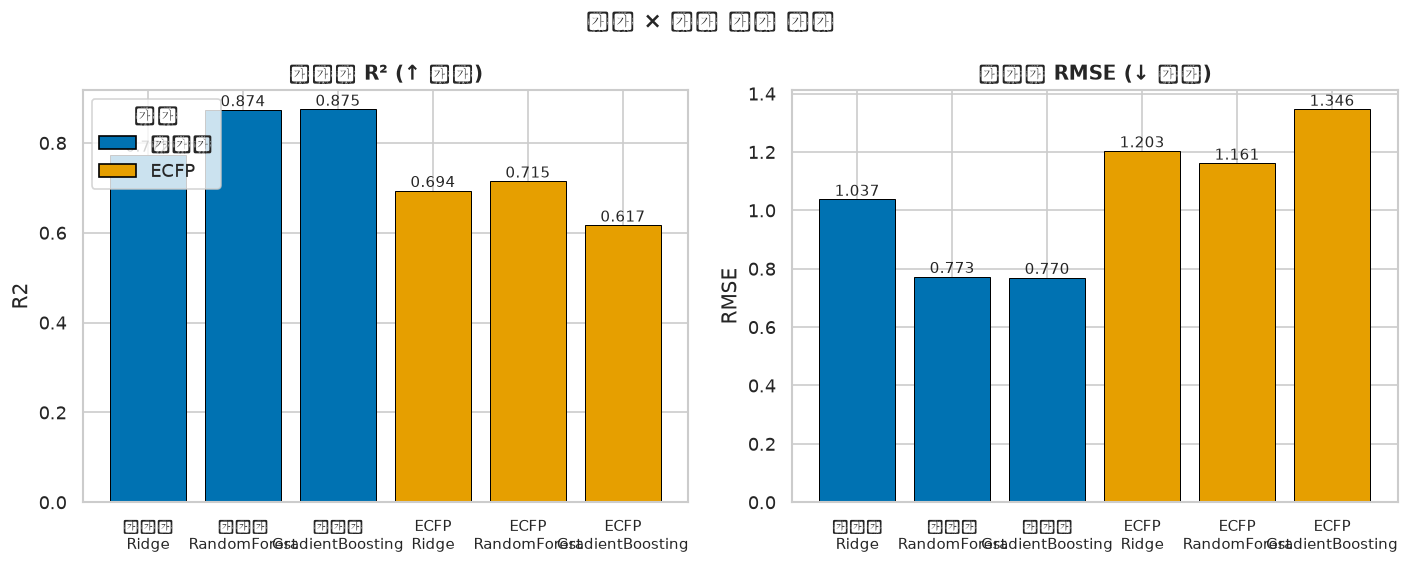

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
combos = [f"{r['표현']}\n{r['모델']}" for _, r in res_df.iterrows()]
colors = [CB[0] if r["표현"] == "기술자" else CB[1] for _, r in res_df.iterrows()]

for ax, (metric, title, better) in zip(
        axes, [("R2", "테스트 R² (↑ 좋음)", "high"),
               ("RMSE", "테스트 RMSE (↓ 좋음)", "low")]):
    vals = res_df[metric].values
    bars = ax.bar(combos, vals, color=colors, edgecolor="black", linewidth=0.6)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", labelsize=9)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v, f"{v:.3f}",
                ha="center", va="bottom", fontsize=9)

# 표현 색상 범례
from matplotlib.patches import Patch
handles = [Patch(facecolor=CB[0], edgecolor="black", label="기술자"),
           Patch(facecolor=CB[1], edgecolor="black", label="ECFP")]
axes[0].legend(handles=handles, title="표현", loc="upper left")
fig.suptitle("표현 × 모델 성능 비교", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


### ② 예측 vs 실측 산점도

최고 성능 조합의 테스트 예측을 실측과 비교합니다. 점들이 **y=x 대각선** 에 가까울수록 정확합니다. R²·RMSE를 주석으로 표시합니다.

/tmp/ipykernel_2940547/4174495447.py:17: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/4174495447.py:17: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/4174495447.py:17: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/4174495447.py:17: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/4174495447.py:17: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/4174495447.py:17: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/4174495447.py:17: UserWarning: Glyph 50756 (\N{HANGUL SYLLABLE WAN}) missing from font(s) DejaVu 

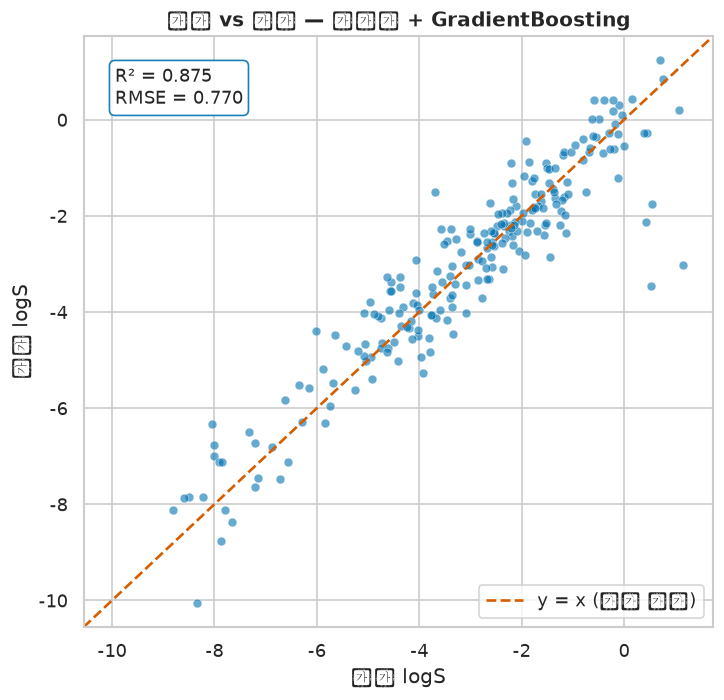

In [11]:
best_rep, best_model = best_row["표현"], best_row["모델"]
yp_best = pred_test[(best_rep, best_model)]

fig, ax = plt.subplots(figsize=(6.2, 6))
ax.scatter(y_te, yp_best, s=28, alpha=0.6, color=CB[0], edgecolor="white", linewidth=0.4)
lo = min(y_te.min(), yp_best.min()) - 0.5
hi = max(y_te.max(), yp_best.max()) + 0.5
ax.plot([lo, hi], [lo, hi], "--", color=CB[3], linewidth=1.6, label="y = x (완벽 예측)")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("실측 logS")
ax.set_ylabel("예측 logS")
ax.set_title(f"예측 vs 실측 — {best_rep} + {best_model}", fontsize=12, fontweight="bold")
ax.text(0.05, 0.95, f"R² = {best_row['R2']:.3f}\nRMSE = {best_row['RMSE']:.3f}",
        transform=ax.transAxes, va="top", ha="left", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor=CB[0], alpha=0.9))
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()


### ③ 잔차 분석 (잔차 vs 예측 · 잔차 히스토그램)

잔차 = 실측 − 예측. 좋은 모델은 잔차가 **0 주변에 무작위** 로 흩어지고(구조/추세 없음), **종 모양** 으로 분포합니다. 특정 예측 구간에서 잔차가 치우치면 편향(bias)을 뜻합니다.

/tmp/ipykernel_2940547/89590086.py:21: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/89590086.py:21: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/89590086.py:21: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/89590086.py:21: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/89590086.py:21: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/89590086.py:21: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/89590086.py:21: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabt

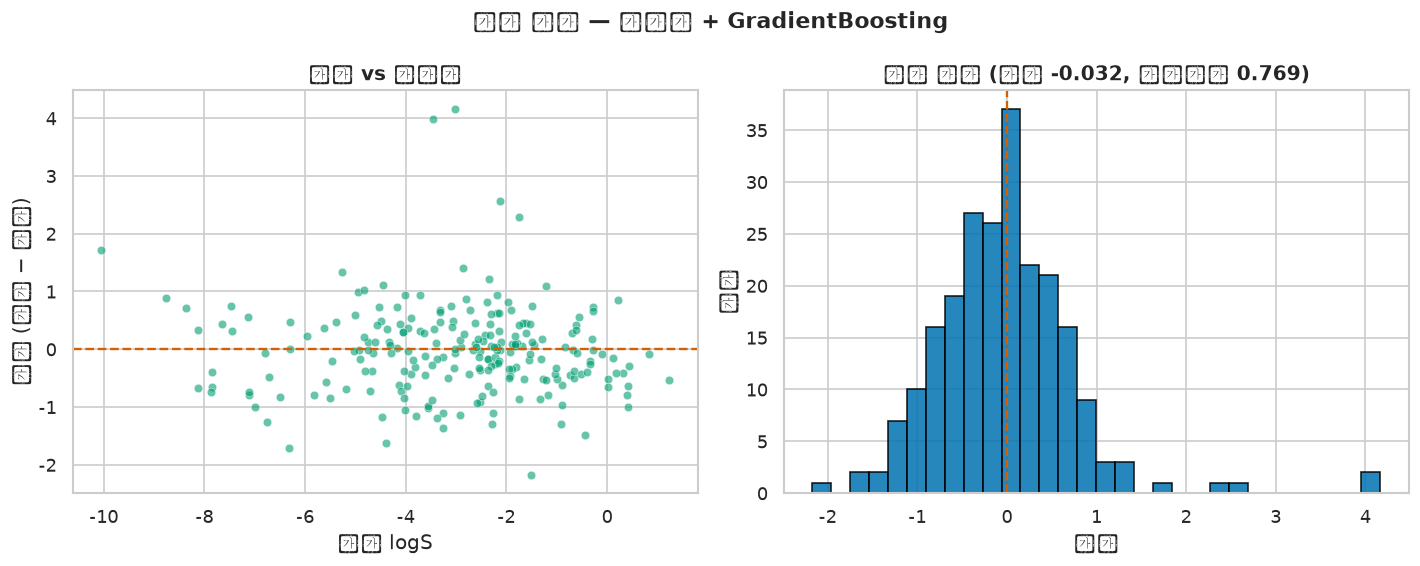

In [12]:
resid = y_te - yp_best

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# (좌) 잔차 vs 예측
axes[0].scatter(yp_best, resid, s=26, alpha=0.6, color=CB[2], edgecolor="white", linewidth=0.4)
axes[0].axhline(0, color=CB[3], linestyle="--", linewidth=1.4)
axes[0].set_xlabel("예측 logS")
axes[0].set_ylabel("잔차 (실측 − 예측)")
axes[0].set_title("잔차 vs 예측값", fontsize=12, fontweight="bold")

# (우) 잔차 히스토그램
axes[1].hist(resid, bins=30, color=CB[0], edgecolor="black", alpha=0.85)
axes[1].axvline(0, color=CB[3], linestyle="--", linewidth=1.4)
axes[1].set_xlabel("잔차")
axes[1].set_ylabel("빈도")
axes[1].set_title(f"잔차 분포 (평균 {resid.mean():.3f}, 표준편차 {resid.std():.3f})",
                  fontsize=12, fontweight="bold")

fig.suptitle(f"잔차 분석 — {best_rep} + {best_model}", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


### ④ y-scrambling 분포 vs 실제 CV R²

라벨을 섞었을 때의 CV R² **분포**(히스토그램)와 **실제 CV R²**(수직선)를 겹쳐 봅니다. 실제 값이 셔플 분포에서 **멀리 오른쪽** 에 있으면, 모델이 우연이 아닌 진짜 구조-용해도 관계를 학습했다는 증거입니다.

/tmp/ipykernel_2940547/3645423440.py:13: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/3645423440.py:13: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/3645423440.py:13: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/3645423440.py:13: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/3645423440.py:13: UserWarning: Glyph 48712 (\N{HANGUL SYLLABLE BIN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/3645423440.py:13: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/3645423440.py:13: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) De

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49492 (\N{HANGUL SYLLABLE SYEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54540 (\N{HANGUL SYLLABLE PEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


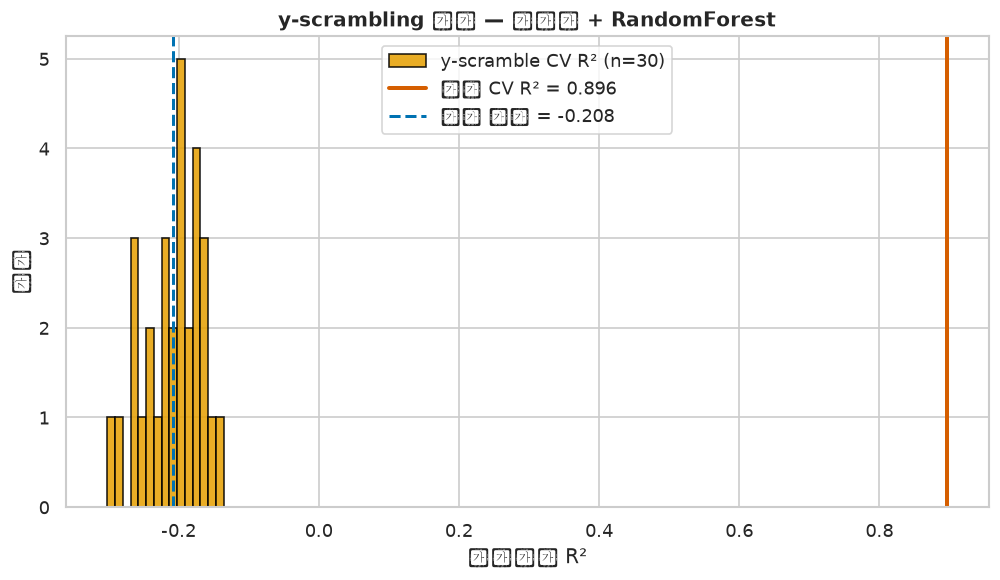

In [13]:
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.hist(scramble_scores, bins=15, color=CB[1], edgecolor="black", alpha=0.85,
        label=f"y-scramble CV R² (n={N_SCRAMBLE})")
ax.axvline(real_cv, color=CB[3], linestyle="-", linewidth=2.4,
           label=f"실제 CV R² = {real_cv:.3f}")
ax.axvline(scramble_scores.mean(), color=CB[0], linestyle="--", linewidth=1.8,
           label=f"셔플 평균 = {scramble_scores.mean():.3f}")
ax.set_xlabel("교차검증 R²")
ax.set_ylabel("빈도")
ax.set_title(f"y-scrambling 검정 — {SCRAMBLE_REP} + {SCRAMBLE_MODEL}",
             fontsize=12, fontweight="bold")
ax.legend(loc="upper center")
fig.tight_layout()
plt.show()


### ⑤ 순열 중요도 (Permutation Importance)

기술자 기반 모델에서 **각 기술자를 무작위로 섞었을 때 성능(R²)이 얼마나 떨어지는지** 로 중요도를 측정합니다(`sklearn.inspection.permutation_importance`). 값이 클수록 예측에 중요한 기술자입니다 — QSAR 해석의 핵심 도구.

/tmp/ipykernel_2940547/869110358.py:18: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/869110358.py:18: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/869110358.py:18: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/869110358.py:18: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/869110358.py:18: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/869110358.py:18: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/869110358.py:18: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.

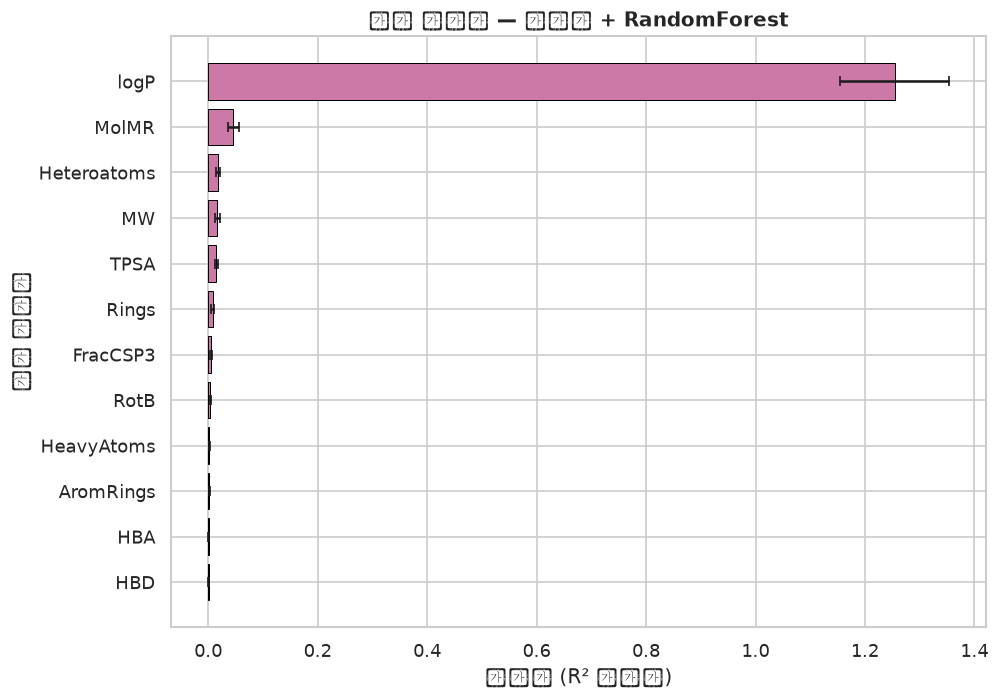

가장 중요한 기술자 Top 3: ['logP', 'MolMR', 'Heteroatoms']


In [14]:
from sklearn.inspection import permutation_importance

# 해석을 위해 기술자 기반 모델 사용 (RandomForest)
imp_model = fitted[("기술자", "RandomForest")]
pi = permutation_importance(imp_model, Xd_te, y_te,
                            n_repeats=20, random_state=42, scoring="r2", n_jobs=-1)
order = np.argsort(pi.importances_mean)   # 오름차순(수평 막대 아래→위)
names_sorted = [desc_names[i] for i in order]
means = pi.importances_mean[order]
stds = pi.importances_std[order]

fig, ax = plt.subplots(figsize=(8.5, 6))
ax.barh(names_sorted, means, xerr=stds, color=CB[4],
        edgecolor="black", linewidth=0.6, capsize=3)
ax.set_xlabel("중요도 (R² 감소량)")
ax.set_ylabel("분자 기술자")
ax.set_title("순열 중요도 — 기술자 + RandomForest", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

top3 = [names_sorted[-i] for i in range(1, 4)]
print("가장 중요한 기술자 Top 3:", top3)


### ⑥ 학습 곡선 (Learning Curve)

학습 데이터 양을 늘려가며 **학습 R²** 와 **교차검증 R²** 가 어떻게 변하는지 봅니다(`sklearn.model_selection.learning_curve`). 두 곡선의 간격이 크면 과적합, 데이터가 늘어도 CV가 오르지 않으면 데이터 추가의 효용이 낮다는 뜻입니다.

/tmp/ipykernel_2940547/419625203.py:20: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/419625203.py:20: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/419625203.py:20: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/419625203.py:20: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/419625203.py:20: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/419625203.py:20: UserWarning: Glyph 44257 (\N{HANGUL SYLLABLE GOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/419625203.py:20: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans

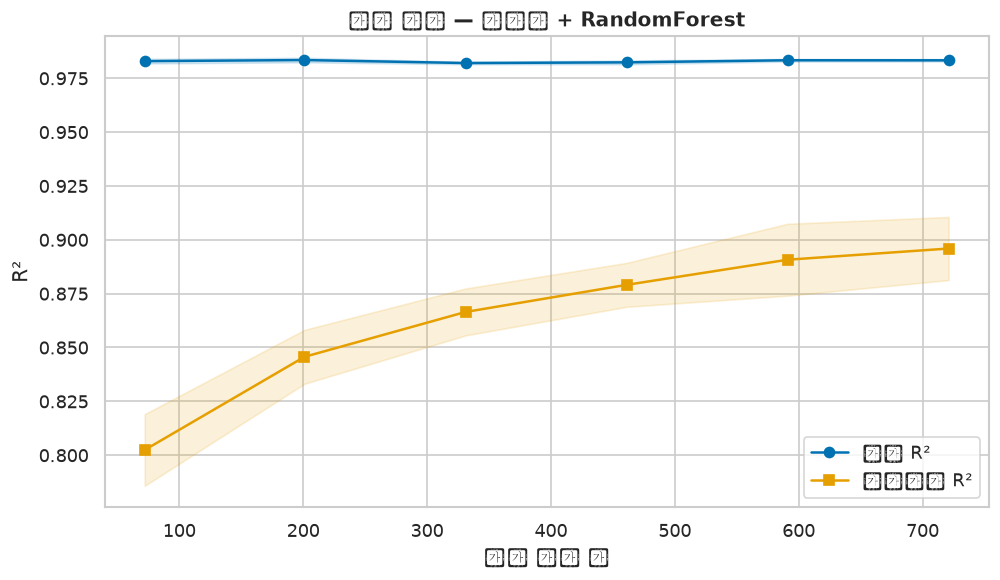

In [15]:
from sklearn.model_selection import learning_curve

lc_model = make_model("RandomForest", reps["기술자"][2])
train_sizes, train_scores, val_scores = learning_curve(
    lc_model, Xd_tr, y_tr, cv=cv, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1)

tr_mean, tr_std = train_scores.mean(1), train_scores.std(1)
va_mean, va_std = val_scores.mean(1), val_scores.std(1)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.plot(train_sizes, tr_mean, "o-", color=CB[0], label="학습 R²")
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, color=CB[0], alpha=0.15)
ax.plot(train_sizes, va_mean, "s-", color=CB[1], label="교차검증 R²")
ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, color=CB[1], alpha=0.15)
ax.set_xlabel("학습 표본 수")
ax.set_ylabel("R²")
ax.set_title("학습 곡선 — 기술자 + RandomForest", fontsize=12, fontweight="bold")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()


### ⑦ Williams plot (적용 범위 시각화)

QSAR 적용 범위의 표준 진단 그림입니다. 가로축은 **leverage(h)**, 세로축은 **표준화 잔차** 입니다.

- **h > h\***(수직 경고선): 입력이 학습 공간에서 벗어난 **외삽/영향점**.
- **|표준화 잔차| > 3**(수평 ±3σ 선): 예측이 크게 빗나간 **이상치**.

두 경고선 안쪽(좌측·중앙)의 분자만 예측을 신뢰할 수 있습니다.

/tmp/ipykernel_2940547/2129775893.py:23: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/2129775893.py:23: UserWarning: Glyph 51456 (\N{HANGUL SYLLABLE JUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/2129775893.py:23: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/2129775893.py:23: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/2129775893.py:23: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/2129775893.py:23: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/2129775893.py:23: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) Deja

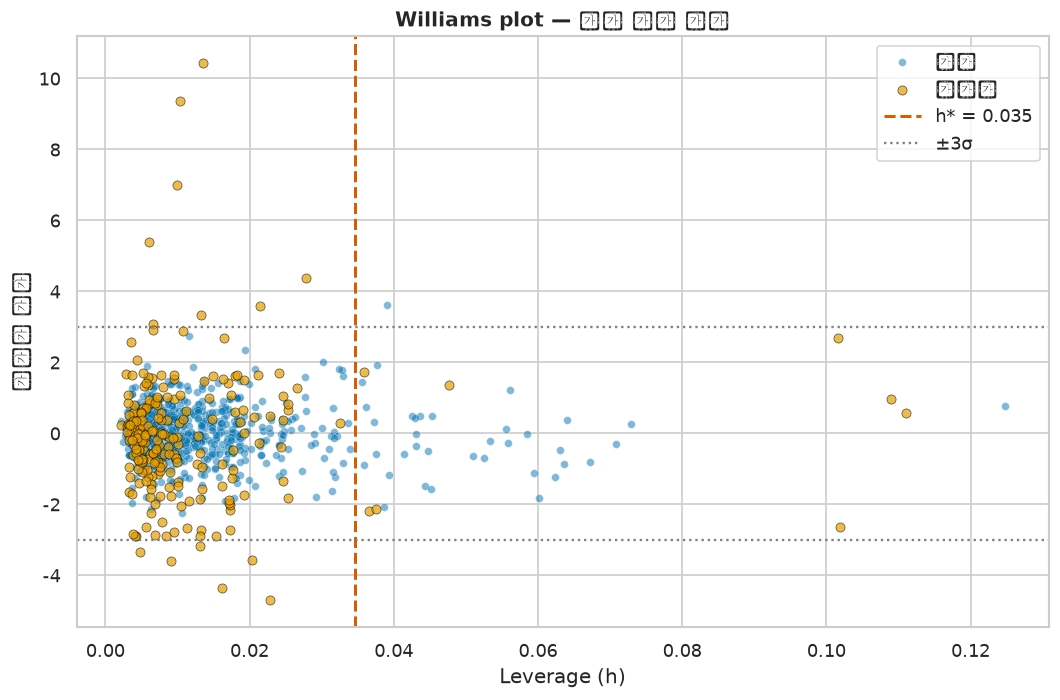

적용범위 경고(외삽 또는 이상치) 분자: 58/1128 (5.1%)


In [16]:
# 전체 분자에 대한 표준화 잔차 (기술자+RandomForest를 전체에 적용해 예측)
#   ※ 학습된 imp_model로 전체 예측 → 잔차 표준화 (진단용 시각화)
yp_all = imp_model.predict(X_desc)
resid_all = logS - yp_all
std_resid_all = resid_all / resid_all.std()

is_test = np.zeros(len(mols), dtype=bool)
is_test[idx_te] = True

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(leverage[~is_test], std_resid_all[~is_test], s=22, alpha=0.5,
           color=CB[0], edgecolor="white", linewidth=0.3, label="학습")
ax.scatter(leverage[is_test], std_resid_all[is_test], s=30, alpha=0.7,
           color=CB[1], edgecolor="black", linewidth=0.4, label="테스트")
ax.axvline(h_star, color=CB[3], linestyle="--", linewidth=1.8,
           label=f"h* = {h_star:.3f}")
ax.axhline(3, color="gray", linestyle=":", linewidth=1.4, label="±3σ")
ax.axhline(-3, color="gray", linestyle=":", linewidth=1.4)
ax.set_xlabel("Leverage (h)")
ax.set_ylabel("표준화 잔차")
ax.set_title("Williams plot — 적용 범위 진단", fontsize=12, fontweight="bold")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

out_ad = ((leverage > h_star) | (np.abs(std_resid_all) > 3))
print(f"적용범위 경고(외삽 또는 이상치) 분자: {out_ad.sum()}/{len(mols)} "
      f"({100*out_ad.mean():.1f}%)")


### ⑧ 기술자 상관 히트맵

기술자들 사이의 **피어슨 상관** 을 봅니다. 강하게 상관된 기술자(예: MW와 HeavyAtoms)는 중복 정보를 담아 선형모델의 계수 해석을 불안정하게 만들 수 있습니다(다중공선성).

/tmp/ipykernel_2940547/1446950259.py:18: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1446950259.py:18: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1446950259.py:18: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1446950259.py:18: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1446950259.py:18: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1446950259.py:18: UserWarning: Glyph 44288 (\N{HANGUL SYLLABLE GWAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1446950259.py:18: UserWarning: Glyph 55176 (\N{HANGUL SYLLABLE HI}) missing from font(s) DejaVu

/tmp/ipykernel_2940547/1446950259.py:18: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1446950259.py:18: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1446950259.py:18: UserWarning: Glyph 49832 (\N{HANGUL SYLLABLE SEUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1446950259.py:18: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/1446950259.py:18: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50612 (\N{HANGUL SYLLABLE EO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49832 (\N{HANGUL SYLLABLE SEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabto

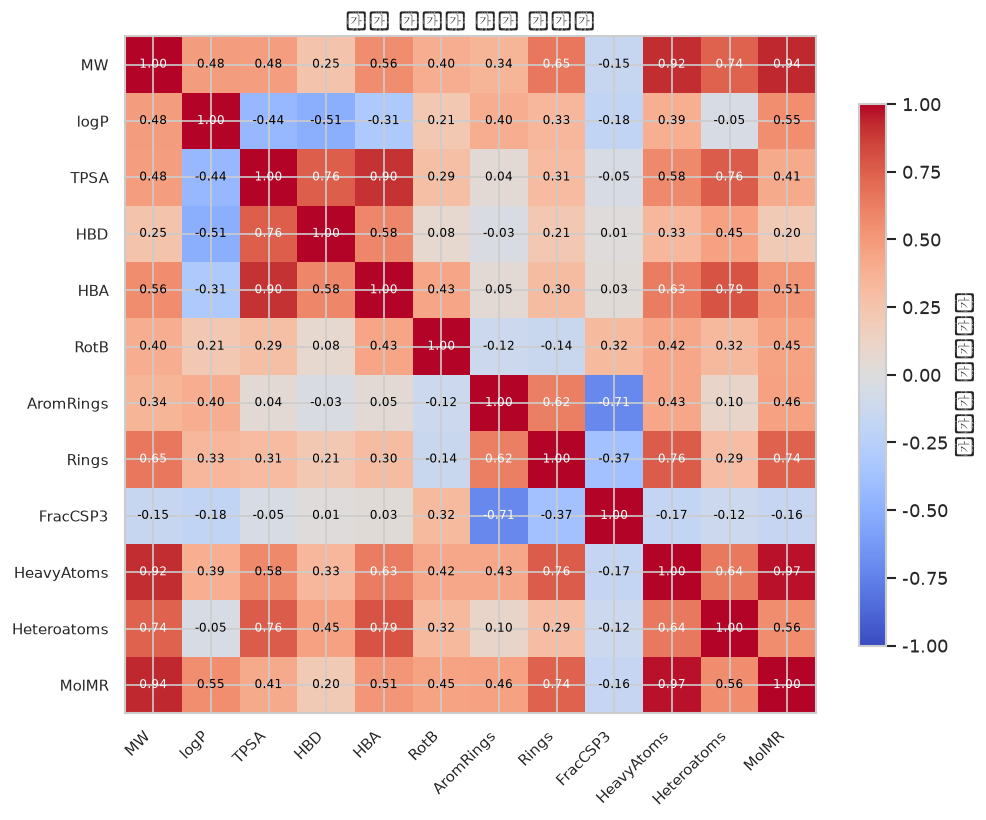

In [17]:
corr = pd.DataFrame(X_desc, columns=desc_names).corr()

fig, ax = plt.subplots(figsize=(8.5, 7))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(desc_names)))
ax.set_yticks(range(len(desc_names)))
ax.set_xticklabels(desc_names, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(desc_names, fontsize=9)
# 셀 값 주석
for i in range(len(desc_names)):
    for j in range(len(desc_names)):
        v = corr.values[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v) > 0.6 else "black", fontsize=7)
cbar = fig.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("피어슨 상관계수")
ax.set_title("분자 기술자 상관 히트맵", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()


## 9. 전이학습 — 사전학습 ChemBERTa로 SMILES 임베딩 추출

지금까지는 사람이 설계한 표현(기술자·ECFP)으로 QSAR을 풀었습니다. 이제 **대규모 SMILES로 사전학습된 언어모델** 의 표현을 빌려 오는 **전이학습(transfer learning)** 을 더합니다.

**ChemBERTa**(Chithrananda et al. 2020)는 수천만 개 SMILES로 **자기지도(MLM) 사전학습**된 RoBERTa입니다. 여기서는 `DeepChem/ChemBERTa-77M-MLM` 을 **동결(frozen)** 해 SMILES → 벡터 임베딩만 뽑습니다.

- `AutoTokenizer` + `AutoModel` 로드, `last_hidden_state` 를 **attention_mask 반영 mean-pool** → 분자당 1벡터
- **64개씩 배치 처리**로 OOM/속도 관리, GPU 있으면 자동 사용(`cuda`)
- 이 벡터를 §11에서 **전통 ML(Ridge/RF)** 입력으로 사용 = **feature-extraction 방식 전이학습**

In [18]:
from transformers import AutoTokenizer, AutoModel

MODEL_NAME = "DeepChem/ChemBERTa-77M-MLM"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
bert = AutoModel.from_pretrained(MODEL_NAME).to(DEVICE).eval()
print("로드 완료:", MODEL_NAME, "| hidden size:", bert.config.hidden_size, "| device:", DEVICE)

@torch.no_grad()
def embed_smiles(smiles_list, batch_size=64, max_len=128):
    """SMILES 리스트 → (N, H) mean-pooled 임베딩. 배치 처리로 메모리 관리."""
    vecs = []
    for i in range(0, len(smiles_list), batch_size):
        chunk = smiles_list[i:i + batch_size]
        enc = tokenizer(chunk, padding=True, truncation=True,
                        max_length=max_len, return_tensors="pt").to(DEVICE)
        out = bert(**enc).last_hidden_state                 # (B, L, H)
        mask = enc["attention_mask"].unsqueeze(-1).float()  # (B, L, 1)
        summed = (out * mask).sum(dim=1)                    # 실제 토큰만 합산
        counts = mask.sum(dim=1).clamp(min=1e-9)            # 패딩 제외 토큰 수
        vecs.append((summed / counts).cpu().numpy())        # mean-pool
        if i % (batch_size * 5) == 0:
            print(f"  임베딩 진행 {min(i + batch_size, len(smiles_list))}/{len(smiles_list)}")
    return np.vstack(vecs)

X_bert = embed_smiles(smiles, batch_size=64)
Xb_tr, Xb_te = X_bert[idx_tr], X_bert[idx_te]
print("ChemBERTa 임베딩 행렬:", X_bert.shape)


/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[transformers] RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MLM
Key                       | Status     | 
--------------------------+------------+-
lm_head.decoder.bias      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


로드 완료: DeepChem/ChemBERTa-77M-MLM | hidden size: 384 | device: cpu
  임베딩 진행 64/1128


  임베딩 진행 384/1128


  임베딩 진행 704/1128


  임베딩 진행 1024/1128
ChemBERTa 임베딩 행렬: (1128, 384)


### (참고) ChemBERTa 임베딩 구조 시각화 — PCA

사전학습 임베딩이 logS와 연속적으로 정렬되어 있는지 2D(PCA)로 투영해 봅니다. 색상이 logS로 매끄럽게 변한다면, 그 표현이 이미 용해도 관련 정보를 담고 있다는 신호입니다.

/tmp/ipykernel_2940547/2346926433.py:11: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/2346926433.py:11: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/2346926433.py:11: UserWarning: Glyph 46377 (\N{HANGUL SYLLABLE DING}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/2346926433.py:11: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/2346926433.py:11: UserWarning: Glyph 50689 (\N{HANGUL SYLLABLE YEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/2346926433.py:11: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Gly

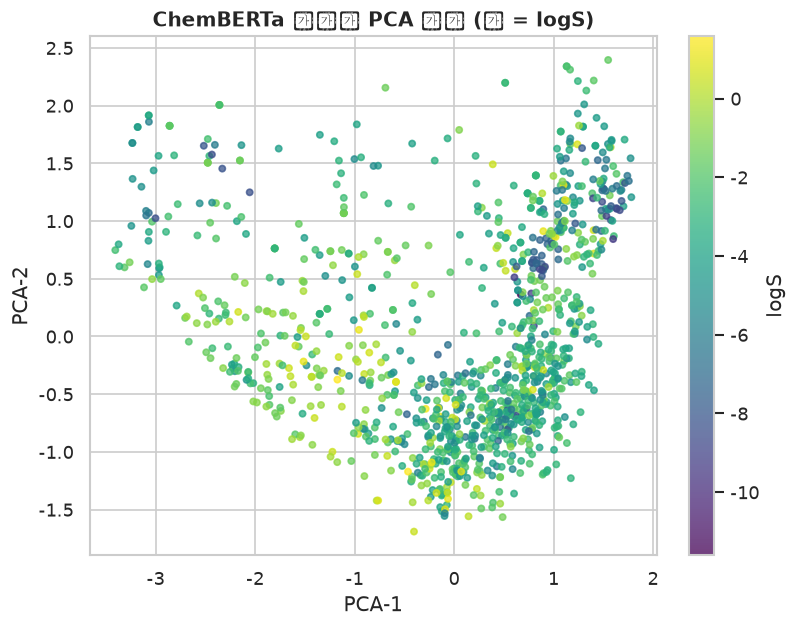

In [19]:
from sklearn.decomposition import PCA

emb2 = PCA(n_components=2, random_state=42).fit_transform(X_bert)

fig, ax = plt.subplots(figsize=(6.8, 5.4))
sc = ax.scatter(emb2[:, 0], emb2[:, 1], c=logS, cmap="viridis", s=14, alpha=0.75)
ax.set_title("ChemBERTa 임베딩 PCA 투영 (색 = logS)", fontsize=12, fontweight="bold")
ax.set_xlabel("PCA-1"); ax.set_ylabel("PCA-2")
cbar = fig.colorbar(sc, ax=ax, fraction=0.046)
cbar.set_label("logS")
fig.tight_layout()
plt.show()


## 10. 표현 4종 정면 비교 — 기술자 · ECFP · 필터 ECFP · ChemBERTa

동일 train/test 분할·동일 지표(R²/RMSE)로 **표현법 4종** 을 각각 **Ridge**(선형)와 **RandomForest**(비선형)에 넣어 logS를 예측합니다. **표현이 곧 모델의 상한선** 임을 실측으로 확인합니다.

- Ridge는 스케일에 민감 → 밀집 실수 표현(기술자·ChemBERTa)에는 `StandardScaler` 를 파이프라인에 포함.
- ECFP는 희소 이진, ChemBERTa/기술자는 밀집 실수 — 표현별 궁합 차이를 관찰.

In [20]:
REPS4 = {
    "기술자":     (Xd_tr,    Xd_te,    True),
    "ECFP":       (Xf_tr,    Xf_te,    False),
    "ECFP(필터)": (Xfilt_tr, Xfilt_te, False),
    "ChemBERTa":  (Xb_tr,    Xb_te,    True),
}
DIMS4 = {k: v[0].shape[1] for k, v in REPS4.items()}

rows4, preds4 = [], {}
for name, (Xtr, Xte, scale) in REPS4.items():
    # Ridge
    rr = make_model("Ridge", scale); rr.fit(Xtr, y_tr); p_ridge = rr.predict(Xte)
    r2_ridge, rmse_ridge = r2_score(y_te, p_ridge), rmse(y_te, p_ridge)
    # RandomForest
    rf = make_model("RandomForest", False); rf.fit(Xtr, y_tr); p_rf = rf.predict(Xte)
    r2_rf, rmse_rf = r2_score(y_te, p_rf), rmse(y_te, p_rf)
    rows4.append({"표현": name, "차원": DIMS4[name],
                  "Ridge R²": round(r2_ridge, 3), "Ridge RMSE": round(rmse_ridge, 3),
                  "RF R²": round(r2_rf, 3), "RF RMSE": round(rmse_rf, 3)})
    preds4[(name, "Ridge")] = (r2_ridge, rmse_ridge, p_ridge)
    preds4[(name, "RF")] = (r2_rf, rmse_rf, p_rf)

board = pd.DataFrame(rows4)
print("=== 표현 × 모델 성능 (동일 test셋, 실측) ===")
print(board.to_string(index=False))

# 표현별 best(두 모델 중 더 좋은 R²)
best_per_rep = {name: max(preds4[(name, "Ridge")][0], preds4[(name, "RF")][0]) for name in REPS4}
best_key4 = max(preds4, key=lambda kk: preds4[kk][0])
print(f"\n전체 최고 조합: {best_key4[0]} + {best_key4[1]}  →  R²={preds4[best_key4][0]:.3f}, "
      f"RMSE={preds4[best_key4][1]:.3f}")
for kk, vv in best_per_rep.items():
    print(f"  - {kk:12s} best R² = {vv:.3f}")


=== 표현 × 모델 성능 (동일 test셋, 실측) ===
       표현   차원  Ridge R²  Ridge RMSE  RF R²  RF RMSE
      기술자   12     0.772       1.037  0.874    0.773
     ECFP 2048     0.694       1.203  0.715    1.161
 ECFP(필터)  368     0.688       1.214  0.721    1.149
ChemBERTa  384     0.785       1.008  0.700    1.190

전체 최고 조합: 기술자 + RF  →  R²=0.874, RMSE=0.773
  - 기술자          best R² = 0.874
  - ECFP         best R² = 0.715
  - ECFP(필터)     best R² = 0.721
  - ChemBERTa    best R² = 0.785


### 표현 4종 성능 막대 그래프

표현별 **최고 test R²**(두 모델 중 더 좋은 값)를 막대로 비교합니다. 색약 친화 팔레트로 표현마다 색을 구분합니다.

/tmp/ipykernel_2940547/3851194096.py:29: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/3851194096.py:29: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/3851194096.py:29: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/3851194096.py:29: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/3851194096.py:29: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/3851194096.py:29: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/3851194096.py:29: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaV

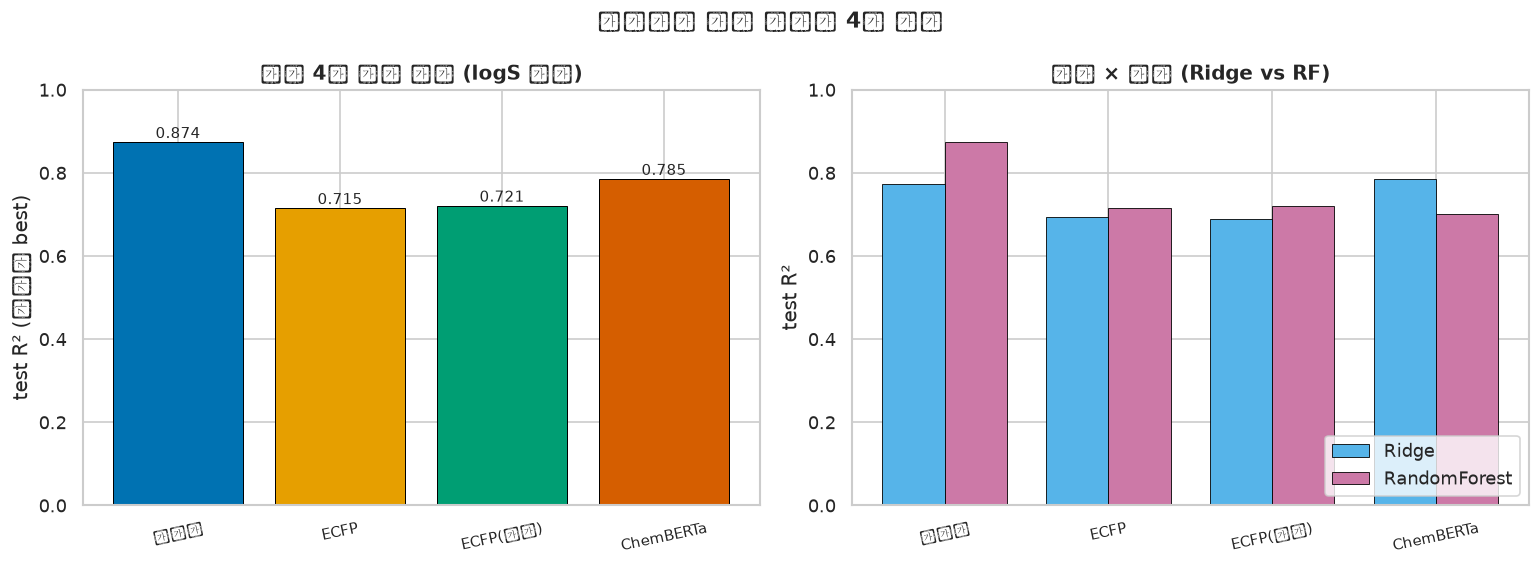

In [21]:
rep_color = {"기술자": CB[0], "ECFP": CB[1], "ECFP(필터)": CB[2], "ChemBERTa": CB[3]}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# (좌) 표현별 best test R²
names4 = list(REPS4.keys())
vals4 = [best_per_rep[nm] for nm in names4]
colors4 = [rep_color[nm] for nm in names4]
bars = axes[0].bar(names4, vals4, color=colors4, edgecolor="black", linewidth=0.6)
axes[0].set_ylabel("test R² (표현별 best)")
axes[0].set_title("표현 4종 성능 비교 (logS 회귀)", fontsize=12, fontweight="bold")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=12, labelsize=9)
for b, v in zip(bars, vals4):
    axes[0].text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

# (우) Ridge vs RF 그룹 막대
x = np.arange(len(names4)); w = 0.38
r_ridge = [preds4[(nm, "Ridge")][0] for nm in names4]
r_rf = [preds4[(nm, "RF")][0] for nm in names4]
axes[1].bar(x - w/2, r_ridge, w, color=CB[5], edgecolor="black", linewidth=0.5, label="Ridge")
axes[1].bar(x + w/2, r_rf, w, color=CB[4], edgecolor="black", linewidth=0.5, label="RandomForest")
axes[1].set_xticks(x); axes[1].set_xticklabels(names4, rotation=12, fontsize=9)
axes[1].set_ylabel("test R²"); axes[1].set_ylim(0, 1)
axes[1].set_title("표현 × 모델 (Ridge vs RF)", fontsize=12, fontweight="bold")
axes[1].legend(loc="lower right")

fig.suptitle("전이학습 포함 표현법 4종 비교", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


## 🔬 보강 A — 결과 시각화 심화

앞의 진단 그림(§8)에 더해, 예측 오차를 **색으로** 드러내고 표현 4종의 성능을 **R²·RMSE 두 지표로 나란히** 비교합니다.
모든 값은 위에서 실제 계산한 배열(`y_te`, `yp_best`, `resid`, `board`)만 사용합니다 — 가상 데이터 없음.

/tmp/ipykernel_2940547/14534858.py:18: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/14534858.py:18: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/14534858.py:18: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/14534858.py:18: UserWarning: Glyph 49353 (\N{HANGUL SYLLABLE SAEG}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/14534858.py:18: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/14534858.py:18: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/14534858.py:18: UserWarning: Glyph 

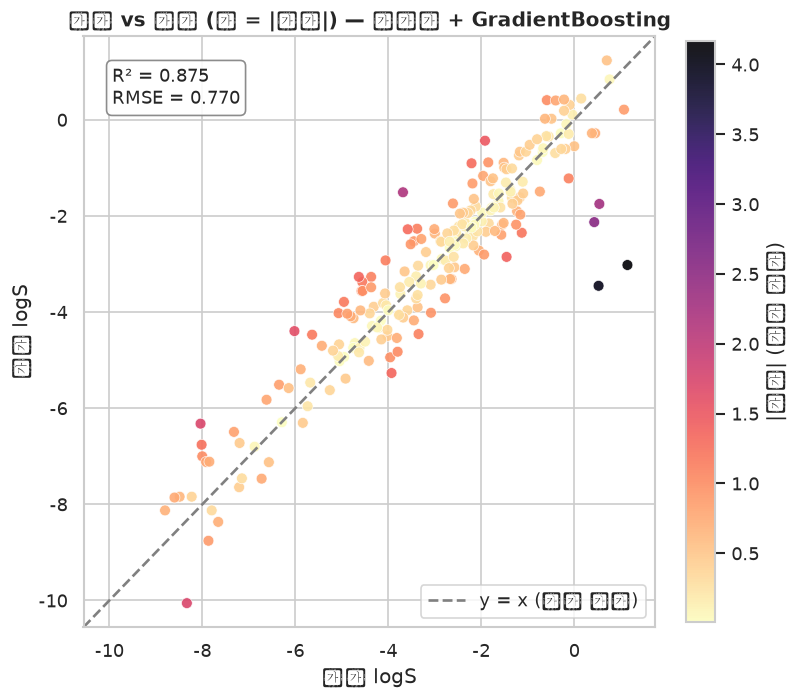

오차 최대 분자 |잔차| = 4.17, 중앙값 = 0.43


In [22]:
# ① 예측 vs 실측 산점도 — 점 색상 = |잔차|(오차 크기)
err_abs = np.abs(resid)                       # resid = y_te - yp_best (테스트셋)
fig, ax = plt.subplots(figsize=(6.8, 6))
sc = ax.scatter(y_te, yp_best, c=err_abs, cmap="magma_r", s=42, alpha=0.9,
                edgecolor="white", linewidth=0.4)
lo = min(y_te.min(), yp_best.min()) - 0.5
hi = max(y_te.max(), yp_best.max()) + 0.5
ax.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=1.6, label="y = x (완벽 예측)")
ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
ax.set_xlabel("실측 logS"); ax.set_ylabel("예측 logS")
ax.set_title(f"예측 vs 실측 (색 = |잔차|) — {best_rep} + {best_model}",
             fontsize=12, fontweight="bold")
cb = fig.colorbar(sc, ax=ax, fraction=0.046); cb.set_label("|잔차| (오차 크기)")
ax.text(0.05, 0.95, f"R² = {best_row['R2']:.3f}\nRMSE = {best_row['RMSE']:.3f}",
        transform=ax.transAxes, va="top", ha="left", fontsize=11,
        bbox=dict(boxstyle="round", facecolor="white", edgecolor="gray", alpha=0.9))
ax.legend(loc="lower right")
fig.tight_layout(); plt.show()
print(f"오차 최대 분자 |잔차| = {err_abs.max():.2f}, 중앙값 = {np.median(err_abs):.2f}")

/tmp/ipykernel_2940547/2421872042.py:19: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/2421872042.py:19: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/2421872042.py:19: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/2421872042.py:19: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/2421872042.py:19: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/2421872042.py:19: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/2421872042.py:19: UserWarn

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 49696 (\N{HANGUL SYLLABLE SUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtoo

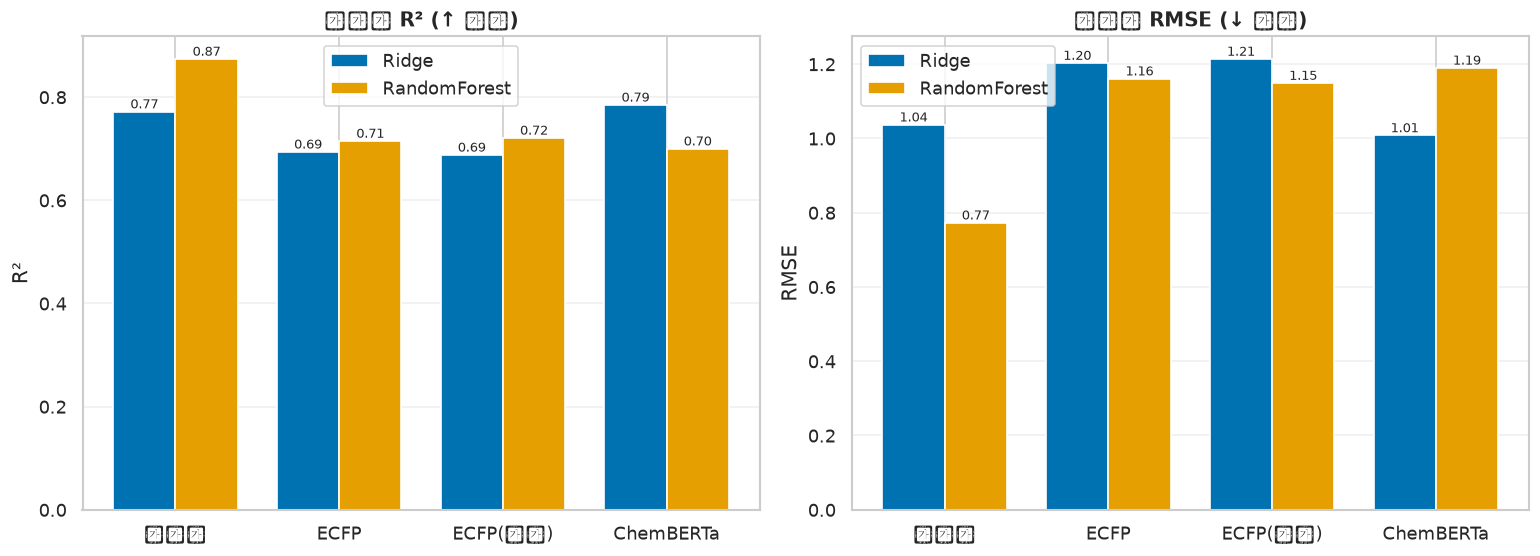

In [23]:
# ② 표현 4종 성능 — R²·RMSE 두 지표 그룹막대 (Ridge vs RandomForest)
names4 = board["표현"].tolist()
x = np.arange(len(names4)); w = 0.38
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

specs = [("R²", "Ridge R²", "RF R²", "테스트 R² (↑ 좋음)"),
         ("RMSE", "Ridge RMSE", "RF RMSE", "테스트 RMSE (↓ 좋음)")]
for ax, (ylab, c_ridge, c_rf, title) in zip(axes, specs):
    b1 = ax.bar(x - w/2, board[c_ridge], w, label="Ridge", color=CB[0])
    b2 = ax.bar(x + w/2, board[c_rf], w, label="RandomForest", color=CB[1])
    ax.set_xticks(x); ax.set_xticklabels(names4)
    ax.set_ylabel(ylab); ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(axis="y", alpha=0.3); ax.legend()
    for bars in (b1, b2):
        for rect in bars:
            h = rect.get_height()
            ax.text(rect.get_x() + rect.get_width()/2, h, f"{h:.2f}",
                    ha="center", va="bottom", fontsize=8)
fig.tight_layout(); plt.show()

/tmp/ipykernel_2940547/2128903019.py:14: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/2128903019.py:14: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/2128903019.py:14: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/2128903019.py:14: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/2128903019.py:14: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/2128903019.py:14: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.tight_layout(); plt.show()
/tmp/ipykernel_2940547/2128903019.py:14: UserW

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylab

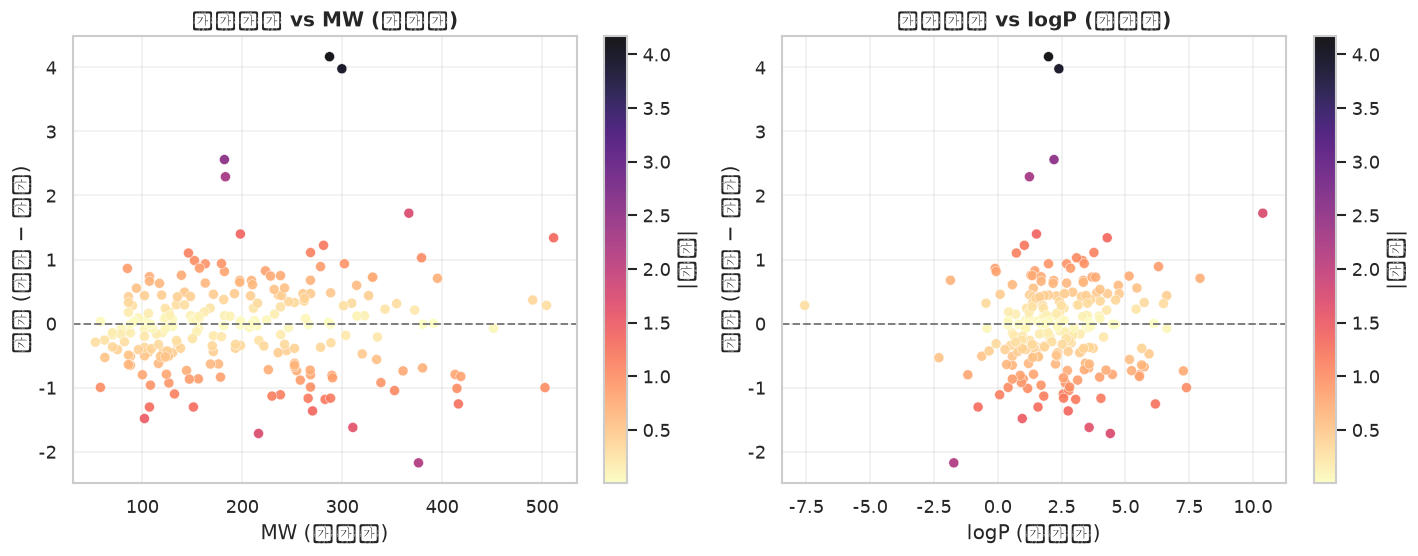

In [24]:
# ③ 예측오차(잔차) vs 주요 기술자 산점 — 오차가 특정 물성 구간에 쏠리는가?
Xd_te_arr = X_desc[idx_te]
pairs = [("MW", "MW (분자량)"), ("logP", "logP (소수성)")]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, (col, lab) in zip(axes, pairs):
    ci = desc_names.index(col)
    scx = ax.scatter(Xd_te_arr[:, ci], resid, c=np.abs(resid), cmap="magma_r",
                     s=36, alpha=0.9, edgecolor="white", linewidth=0.3)
    ax.axhline(0, color="gray", linestyle="--", linewidth=1.2)
    ax.set_xlabel(lab); ax.set_ylabel("잔차 (실측 − 예측)")
    ax.set_title(f"예측오차 vs {lab}", fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3)
    cb = fig.colorbar(scx, ax=ax, fraction=0.046); cb = cb; cb.set_label("|잔차|")
fig.tight_layout(); plt.show()

## 🔬 보강 B — 화합물 구조로 보는 예측 진단 (RDKit)

숫자·산점도만으로는 "어떤 분자를 잘/못 맞추는가"가 보이지 않습니다.
테스트셋에서 **가장 정확한 6개(|잔차| 최소)** 와 **가장 크게 틀린 6개(|잔차| 최대)** 의 실제 구조를 그려
정확/오차 분자의 구조적 특징을 눈으로 비교합니다. 범례는 `실제 / 예측` 값입니다.

/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu San

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


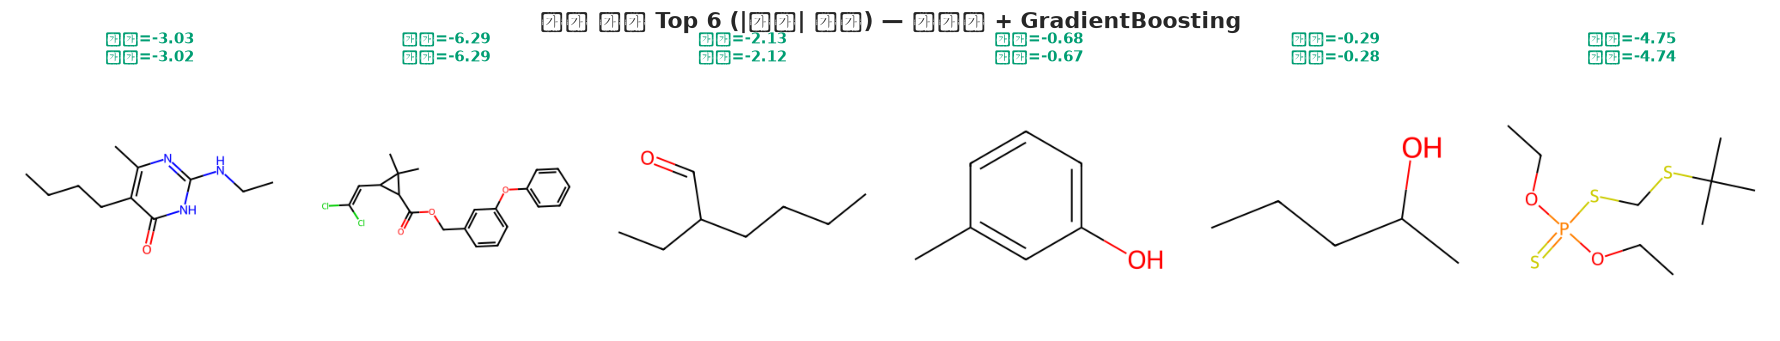

/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 53360 (\N{HANGUL SYLLABLE KEUN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 53360 (\N{HANGUL SYLLABLE KEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


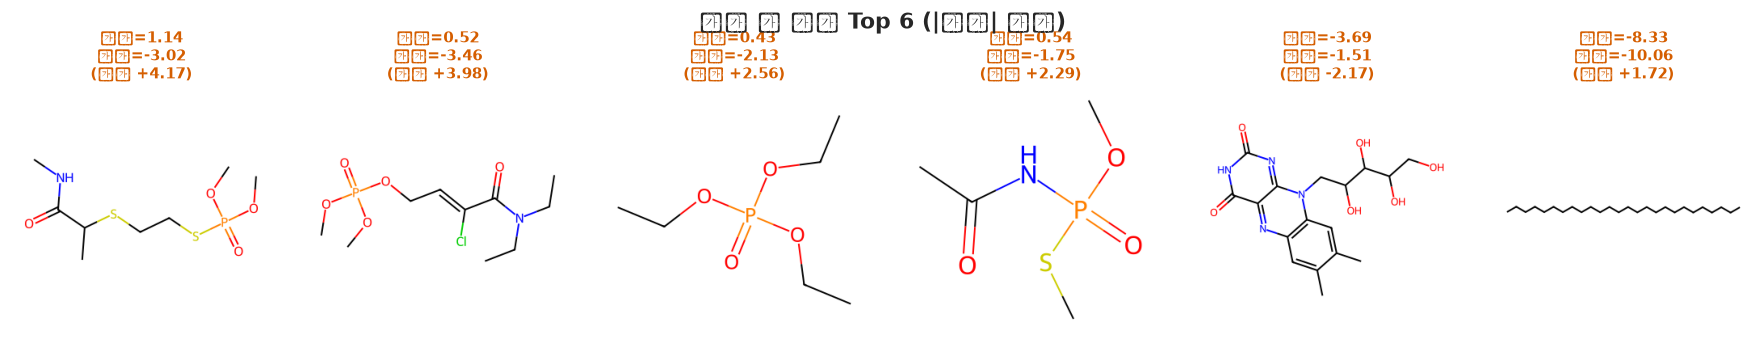

In [25]:
from rdkit.Chem import Draw

def _draw_struct_grid(global_idx, titles, title_colors=None, ncols=6,
                      per=(2.5, 2.9), subsize=(320, 300), suptitle=None):
    """mols[global_idx] 구조를 matplotlib 그리드로 그림 (한글 제목 = NanumGothic 사용)."""
    n = len(global_idx)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(per[0]*ncols, per[1]*nrows))
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        ax.axis("off")
    for a, (gi, ttl) in enumerate(zip(global_idx, titles)):
        img = Draw.MolToImage(mols[gi], size=subsize)
        axes[a].imshow(img)
        c = title_colors[a] if title_colors else "black"
        axes[a].set_title(ttl, fontsize=9, color=c, fontweight="bold")
    if suptitle:
        fig.suptitle(suptitle, fontsize=13, fontweight="bold")
    fig.tight_layout()
    plt.show()

abs_resid = np.abs(resid)
order = np.argsort(abs_resid)          # 테스트셋 상대 인덱스 (오름차순)
acc_pos = order[:6]                    # |잔차| 최소 = 정확
err_pos = order[-6:][::-1]             # |잔차| 최대 = 오차 큼

_draw_struct_grid(
    [idx_te[j] for j in acc_pos],
    [f"실제={y_te[j]:.2f}\n예측={yp_best[j]:.2f}" for j in acc_pos],
    title_colors=[CB[2]]*6,
    suptitle=f"정확 예측 Top 6 (|잔차| 최소) — {best_rep} + {best_model}")

_draw_struct_grid(
    [idx_te[j] for j in err_pos],
    [f"실제={y_te[j]:.2f}\n예측={yp_best[j]:.2f}\n(잔차 {resid[j]:+.2f})" for j in err_pos],
    title_colors=[CB[3]]*6,
    suptitle="오차 큰 예측 Top 6 (|잔차| 최대)")

### 적용범위(AD) 밖 분자 — 신뢰 낮은 예측 예시

§7에서 계산한 kNN 거리(`knn_te`)로 학습 공간에서 **가장 멀리 떨어진** 테스트 분자 6개를 구조로 봅니다.
이런 분자는 외삽(extrapolation) 영역이라 예측 신뢰도가 낮습니다. `⚠h>h*` 는 leverage 경고선도 함께 넘은 경우입니다.

/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.


/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44144 (\N{HANGUL SYLLABLE GEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pyla

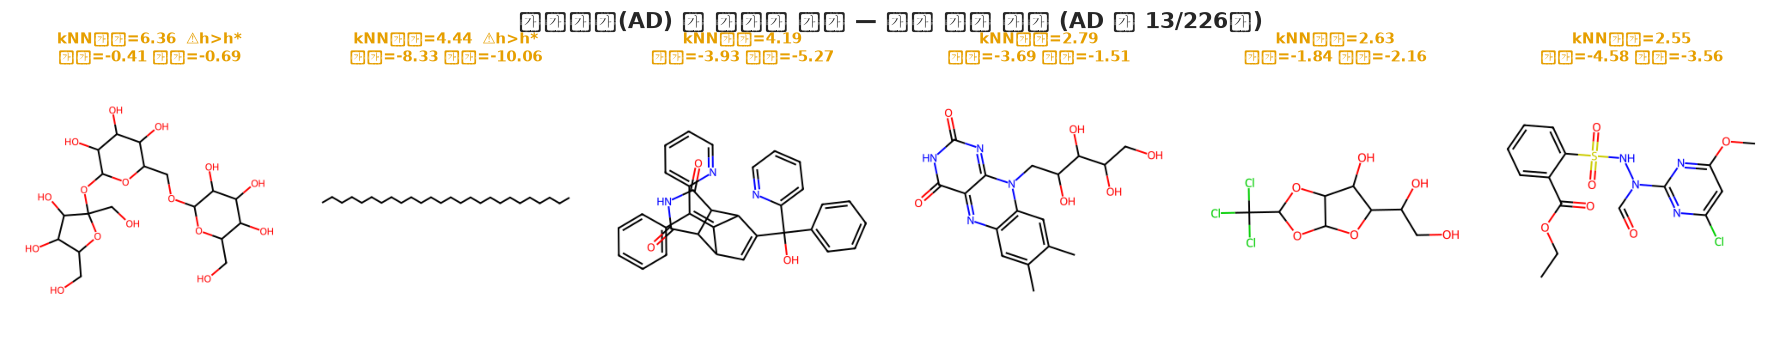

AD 임계값(학습 95백분위 kNN거리) = 1.930


In [26]:
ad_order = np.argsort(knn_te)[::-1]      # kNN 거리 큰 순 (가장 밖)
sel = ad_order[:6]
lev_te = leverage[idx_te]                # 테스트 분자의 leverage
n_out = int((~in_domain).sum())

titles = []
for j in sel:
    warn = "  ⚠h>h*" if lev_te[j] > h_star else ""
    titles.append(f"kNN거리={knn_te[j]:.2f}{warn}\n실제={y_te[j]:.2f} 예측={yp_best[j]:.2f}")

_draw_struct_grid(
    [idx_te[j] for j in sel], titles, title_colors=[CB[1]]*len(sel),
    suptitle=f"적용범위(AD) 밖 테스트 분자 — 신뢰 낮은 예측 (AD 밖 {n_out}/{len(knn_te)}개)")
print(f"AD 임계값(학습 95백분위 kNN거리) = {ad_threshold:.3f}")

### ChemBERTa 임베딩 PCA 극단 분자

§9의 ChemBERTa 임베딩 2D-PCA(`emb2`)에서 **네 극단**(PC1/PC2 최소·최대)에 위치한 분자 구조를 봅니다.
사전학습 표현 공간의 양 끝에 어떤 화학 구조가 놓이는지 확인합니다.

/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()


/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 46377 (\N{HANGUL SYLLABLE DING}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 44537 (\N{HANGUL SYLLABLE GEUG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_2940547/326915766.py:19: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.

/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 48288 (\N{HANGUL SYLLABLE BE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 46377 (\N{HANGUL SYLLABLE DING}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 44537 (\N{HANGUL SYLLABLE GEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/hjpark/lecture_drug1/.venv_slides/lib/python3.12/site-packages/IPython/core/pylabt

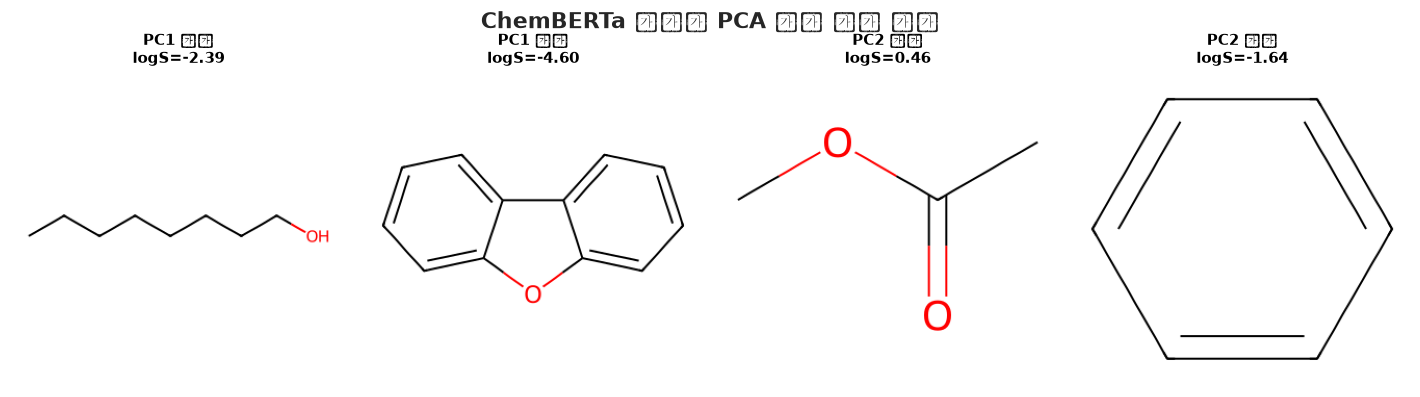

In [27]:
ext = {
    "PC1 최소": int(np.argmin(emb2[:, 0])),
    "PC1 최대": int(np.argmax(emb2[:, 0])),
    "PC2 최소": int(np.argmin(emb2[:, 1])),
    "PC2 최대": int(np.argmax(emb2[:, 1])),
}
_draw_struct_grid(
    list(ext.values()),
    [f"{k}\nlogS={logS[v]:.2f}" for k, v in ext.items()],
    ncols=4, per=(3.0, 3.4),
    suptitle="ChemBERTa 임베딩 PCA 극단 분자 구조")

## 🔬 보강 C — 실제 화합물로 검증

학습된 **최고 모델**을 (1) 교과서적으로 유명한 실제 약물과 (2) 테스트셋의 실측값을 아는 분자에 적용해
"진짜로 쓸 만한가"를 확인합니다.

- **외부 약물 예측**: aspirin·caffeine·ibuprofen·paracetamol 등 → 최고 모델로 `logS` **예측**.
  ESOL 학습 데이터에 이미 있는 분자면 데이터셋 실측값도 함께 표기하고, 없으면 **예측값만**('예측' 명시)합니다.
  (실험값을 임의로 만들어내지 않습니다 — 무-날조.)
- **테스트셋 외부검증**: 모델이 학습 때 보지 못한 테스트 분자 6개를 골라 `구조 + 실제 logS + 예측 logS + 오차`로 제시.

검증에 사용할 최고 모델: 기술자 + GradientBoosting (테스트 R²=0.875, RMSE=0.770)

=== 외부 약물 logS 예측 (무-날조: 실측은 ESOL에 있을 때만) ===
         약물  예측 logS ESOL 실측 logS           출처
    aspirin    -2.17            - 데이터셋 외부(예측만)
   caffeine    -1.51        -0.88       학습셋 포함
  ibuprofen    -3.35            - 데이터셋 외부(예측만)
paracetamol    -1.88        -1.03       학습셋 포함
    benzene    -1.79        -1.64       학습셋 포함
    glucose     0.41         0.74       학습셋 포함


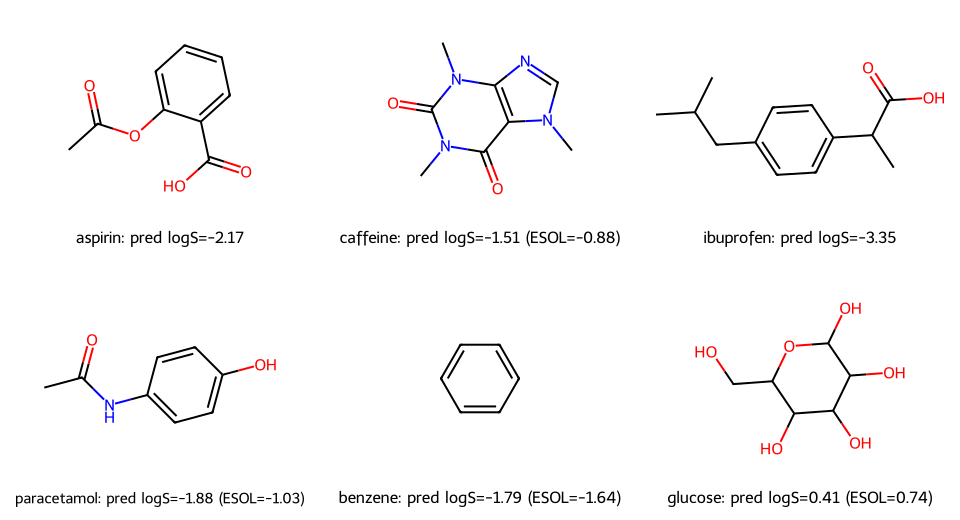

In [28]:
from rdkit.Chem import Draw

# --- 최고 모델(6조합 중 R² 최고)과 표현 준비 ---
best_est = fitted[(best_rep, best_model)]
print(f"검증에 사용할 최고 모델: {best_rep} + {best_model} "
      f"(테스트 R²={best_row['R2']:.3f}, RMSE={best_row['RMSE']:.3f})")

def featurize(mol_list, rep):
    """학습과 동일한 방식으로 새 분자를 표현 벡터로 변환."""
    if rep == "기술자":
        return np.array([[float(fn(m)) for fn in DESCRIPTORS.values()]
                         for m in mol_list], dtype=float)
    elif rep == "ECFP":
        return np.array([list(mgen.GetFingerprint(m)) for m in mol_list],
                        dtype=np.float64)
    raise ValueError(rep)

# 학습 데이터 정규 SMILES 집합 (중복/존재 여부 판정용)
canon_train = {}
for gi in idx_tr:
    canon_train[Chem.MolToSmiles(mols[gi])] = gi
canon_test = {Chem.MolToSmiles(mols[gi]): gi for gi in idx_te}

drugs = {
    "aspirin":     "CC(=O)Oc1ccccc1C(=O)O",
    "caffeine":    "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "ibuprofen":   "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "paracetamol": "CC(=O)Nc1ccc(O)cc1",
    "benzene":     "c1ccccc1",
    "glucose":     "OCC1OC(O)C(O)C(O)C1O",
}

d_mols, d_names, d_legends, d_rows = [], [], [], []
for name, smi in drugs.items():
    m = Chem.MolFromSmiles(smi)
    if m is None:
        print(f"[파싱 실패] {name}: {smi}")
        continue
    x = featurize([m], best_rep)
    pred = float(best_est.predict(x)[0])
    cs = Chem.MolToSmiles(m)
    if cs in canon_train:
        note, actual = "학습셋 포함", logS[canon_train[cs]]
    elif cs in canon_test:
        note, actual = "테스트셋 포함", logS[canon_test[cs]]
    else:
        note, actual = "데이터셋 외부(예측만)", np.nan
    d_mols.append(m); d_names.append(name)
    # 범례는 ASCII (RDKit 그리드 폰트 한글 미지원 회피)
    leg = f"{name}: pred logS={pred:.2f}"
    if not np.isnan(actual):
        leg += f" (ESOL={actual:.2f})"
    d_legends.append(leg)
    d_rows.append({"약물": name, "예측 logS": round(pred, 2),
                   "ESOL 실측 logS": ("-" if np.isnan(actual) else round(actual, 2)),
                   "출처": note})

drug_df = pd.DataFrame(d_rows)
print("\n=== 외부 약물 logS 예측 (무-날조: 실측은 ESOL에 있을 때만) ===")
print(drug_df.to_string(index=False))

img = Draw.MolsToGridImage(d_mols, molsPerRow=3, subImgSize=(320, 260),
                           legends=d_legends)
from IPython.display import display
display(img)

=== 테스트셋 외부검증 (모델이 학습에 사용하지 않은 분자) ===
                          SMILES  실제 logS  예측 logS  오차(실−예)  |오차|
                  CC(C)c1ccccc1C    -3.76    -4.05     0.29  0.29
                       O=C1CCCN1     1.07     0.21     0.86  0.86
              CC(=O)Nc1ccc(F)cc1    -1.78    -1.84     0.06  0.06
Cc3cc2nc1c(=O)[nH]c(=O)nc1n(CC(O    -3.69    -1.51    -2.17  2.17
                      CC(C)C(C)C    -3.65    -3.16    -0.49  0.49
 CCN2c1ncccc1N(C)C(=S)c3cccnc23     -4.63    -3.27    -1.36  1.36

표본 6개 평균 |오차| = 0.87 logS


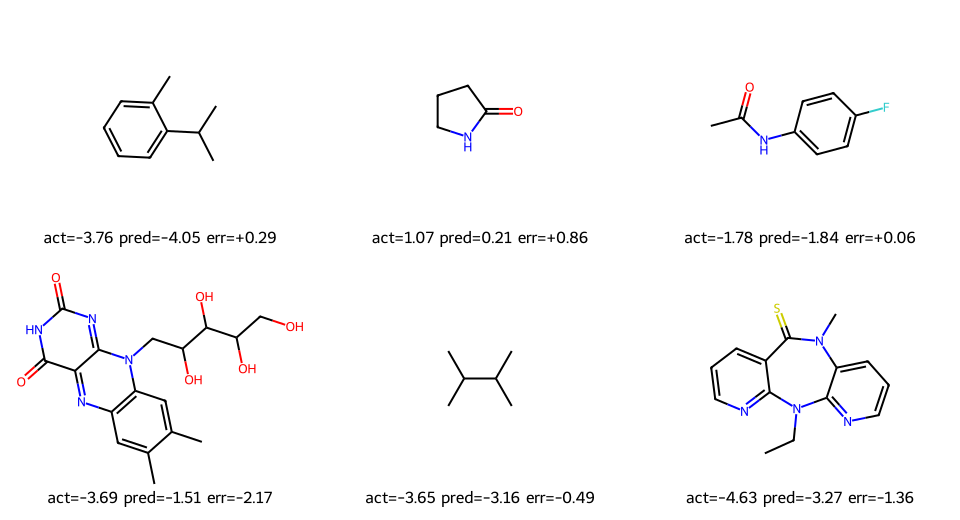

In [29]:
# --- 테스트셋 외부검증: 학습 때 보지 못한 분자 6개 (구조 + 실측 + 예측 + 오차) ---
# 재현성 위해 고정 시드로 테스트 인덱스 6개 샘플
rng = np.random.default_rng(42)
pick = np.sort(rng.choice(len(idx_te), size=6, replace=False))

ext_rows, ext_mols, ext_legends = [], [], []
for j in pick:
    gi = idx_te[j]
    act = float(y_te[j]); prd = float(yp_best[j]); err = act - prd
    ext_rows.append({"SMILES": smiles[gi][:32],
                     "실제 logS": round(act, 2),
                     "예측 logS": round(prd, 2),
                     "오차(실−예)": round(err, 2),
                     "|오차|": round(abs(err), 2)})
    ext_mols.append(mols[gi])
    ext_legends.append(f"act={act:.2f} pred={prd:.2f} err={err:+.2f}")

extval_df = pd.DataFrame(ext_rows)
print("=== 테스트셋 외부검증 (모델이 학습에 사용하지 않은 분자) ===")
print(extval_df.to_string(index=False))
print(f"\n표본 6개 평균 |오차| = {extval_df['|오차|'].mean():.2f} logS")

img2 = Draw.MolsToGridImage(ext_mols, molsPerRow=3, subImgSize=(320, 260),
                            legends=ext_legends)
from IPython.display import display
display(img2)

## 11. 개념 — MolCLR류 사전학습 표현으로 전이학습

이 노트북의 §9–10이 바로 **자기지도 사전학습 표현으로 특징을 뽑아 전통 ML에 전이**하는 방식입니다. 라벨이 없는 방대한 SMILES로 먼저 표현(임베딩)을 학습해 두면, 라벨이 적은 다운스트림 과제(여기서는 logS 회귀)에서 그 임베딩을 **고정 특징(feature extractor)** 으로 재사용해 Ridge/RandomForest 같은 가벼운 모델만 학습하면 됩니다. 전체 딥러닝 모델을 fine-tuning하지 않고도, 사전학습이 담아 둔 화학 지식을 그대로 빌려 쓰는 셈입니다.

**MolCLR (그래프 기반 동종 접근).** MolCLR(Wang et al., *Nature Machine Intelligence* 2022; 저장소 `yuyangw/MolCLR`)은 SMILES 시퀀스가 아니라 **분자 그래프**를 대상으로 그래프신경망(GNN)을 **대조학습(contrastive learning)** 으로 자기지도 사전학습합니다. 원자 마스킹·결합 삭제·부분구조 제거 같은 그래프 증강으로 같은 분자의 두 뷰를 가깝게, 다른 분자를 멀게 학습해 범용 분자 표현을 얻고, 이를 다운스트림 물성/활성 예측에 전이합니다 — 본 실습의 ChemBERTa(시퀀스 기반)와 **표현 modality만 다른 같은 철학**의 전이학습입니다.

다만 MolCLR은 그래프 GNN 스택(예: PyTorch Geometric) 설치가 무거워, 이 실습에서는 설치가 가벼운 **SMILES 기반 ChemBERTa로 시연**하고 MolCLR은 개념(선택·고급)으로만 소개합니다. 실무에서는 대상 데이터의 modality(시퀀스 vs 그래프)와 도메인에 맞춰 사전학습 표현을 고르고, feature-extraction → (여유가 되면) fine-tuning 순서로 확장합니다.

## 12. 요약 · 한계 · 참고문헌

**요약**
- 시리즈 01에서 만든 **분자 특징(기술자·ECFP·필터 ECFP)** 으로 Ridge·RandomForest·GradientBoosting QSAR 회귀를 학습·비교했습니다.
- 성능은 **테스트 R²/RMSE + 5-fold CV** 로 평가하고, **y-scrambling** 으로 우연 상관이 아님을 확인했습니다.
- **적용 범위(kNN 거리·leverage·Williams plot)** 로 예측을 신뢰할 수 있는 분자 영역을 정의했습니다.
- **8종 결과분석 시각화** 로 모델을 다각도 진단하고, **사전학습 ChemBERTa 임베딩** 을 더해 **표현 4종** 을 정면 비교했습니다(전이학습).

**한계 (무-날조 원칙)**
- ESOL은 약 1,128 분자의 **단일 물성(수용해도)** 데이터로, 규모가 크지 않고 화학공간이 제한적입니다 → 신약 화합물 전반으로의 일반화는 제한적.
- 측정 수용해도 자체에 실험 오차가 있으며, 여기서 계산된 지표는 **이 데이터·이 분할·이 하이퍼파라미터** 조건의 결과입니다(다른 분할·조건에서 값이 달라질 수 있음).
- 하이퍼파라미터는 시연을 위해 고정값을 사용했고 별도 튜닝(중첩 CV)·scaffold split·fine-tuning 은 하지 않았습니다 → 실제 배포 전에는 튜닝·외부 검증이 필요합니다.
- 적용 범위 밖(Williams plot 경고 영역) 분자의 예측은 신뢰하지 않는 것이 원칙입니다.
- 모든 수치는 이 노트북이 실제 계산한 값이며, 가상 데이터·임의 분포는 사용하지 않았습니다.

**참고문헌 (실재)**
1. Delaney, J. S. (2004). *ESOL: Estimating Aqueous Solubility Directly from Molecular Structure.* J. Chem. Inf. Comput. Sci., 44(3), 1000–1005. https://doi.org/10.1021/ci034243x
2. Tropsha, A. (2010). *Best Practices for QSAR Model Development, Validation, and Exploitation.* Mol. Inf., 29(6–7), 476–488. https://doi.org/10.1002/minf.201000061
3. Rogers, D., & Hahn, M. (2010). *Extended-Connectivity Fingerprints.* J. Chem. Inf. Model., 50(5), 742–754. https://doi.org/10.1021/ci100050t
4. Chithrananda, S., Grand, G., & Ramsundar, B. (2020). *ChemBERTa: Large-Scale Self-Supervised Pretraining for Molecular Property Prediction.* arXiv:2010.09885.
5. Wang, Y., Wang, J., Cao, Z., & Barati Farimani, A. (2022). *Molecular Contrastive Learning of Representations via Graph Neural Networks (MolCLR).* Nature Machine Intelligence, 4, 279–287. https://doi.org/10.1038/s42256-022-00447-x
6. RDKit: Open-source cheminformatics. https://www.rdkit.org
